# MIP discriminators
#### Exploration of values that could serve as MIP discriminator

In [1]:
import ROOT, os, json, copy, time
from pathlib import Path
import uproot
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import Normalize

from ddfUtils.mpl_styling import add_label
import ddfUtils.root as ddf_root

plt.style.use("root")

ROOT.gROOT.SetBatch(True)

In [ ]:
DATA_DIR = Path("/eos/user/i/idioniso/sndMuTri/out")
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT = DATA_DIR / "pGun_response.root"

PGUN_DIR = Path("/eos/user/i/idioniso/1_Data/Monte_Carlo/pGun/muons")
MC_PATH = Path(
    "/eos/user/i/idioniso/sndMuTri/data/cutset8/trimuon_boost100/trimuon_digCPP_hough_cutset8.parquet"
)

ENERGY_DIRS = [
    "10.GeV",
    "12.5.GeV",
    "15.GeV",
    "17.5.GeV",
    "20.GeV",
    "25.GeV",
    "30.GeV",
    "35.GeV",
    "55.GeV",
    "100.GeV",
    "200.GeV",
    "300.GeV",
    "450.GeV",
    "600.GeV",
    "800.GeV",
    "1010.GeV",
]

## Data extraction

In [ ]:
raw_events_sf = {}
raw_events_ds = {}

for edir in ENERGY_DIRS:
  dir_path = PGUN_DIR / edir
  digi_file = dir_path / "sndLHC.PG_13-TGeant4_digCPP.root"
  print(digi_file)
  if not digi_file.exists():
    continue

  energy_val = float(edir.replace(".GeV", "").replace("GeV", ""))
  f = ROOT.TFile.Open(str(digi_file))
  if not f or f.IsZombie():
    print(f"Skipping corrupt file: {digi_file}")
    continue

  tree = f.Get("cbmsim")
  if not tree:
    f.Close()
    continue

  n_entries = tree.GetEntries()
  hits_sf_list, qdc_sf_list = [], []
  hits_ds_list, qdc_ds_list = [], []

  for i in range(n_entries):
    tree.GetEntry(i)

    # 1. SciFi Response (10 planes)
    valid_sf_signals = [
        h.GetSignal() for h in tree.Digi_ScifiHits if h.isValid()
    ]
    n_sf = len(valid_sf_signals)
    hits_sf_list.append(n_sf / 10.0)
    qdc_sf_list.append(sum(valid_sf_signals) / 10.0)

    ds_hits = [
        h for h in tree.Digi_MuFilterHits if h.GetSystem() == 3 and h.isValid()
    ]
    n_ds = len(ds_hits)
    hits_ds_list.append(n_ds / 4.0)
    tot_ds_qdc = sum(v for h in ds_hits for k, v in h.GetAllSignals())
    qdc_ds_list.append(tot_ds_qdc / 4.0)

  f.Close()

  if len(hits_sf_list) > 0:
    raw_events_sf[energy_val] = {
        "hits_plane": np.array(hits_sf_list),
        "qdc_plane": np.array(qdc_sf_list),
    }
  if len(hits_ds_list) > 0:
    raw_events_ds[energy_val] = {
        "hits_plane": np.array(hits_ds_list),
        "qdc_plane": np.array(qdc_ds_list),
    }

In [ ]:
sf_mip_hits = np.concatenate(
    [data["hits_plane"] for E, data in raw_events_sf.items() if E <= 40]
)
sf_mip_qdc = np.concatenate(
    [data["qdc_plane"] for E, data in raw_events_sf.items() if E <= 40]
)

ds_mip_hits = np.concatenate(
    [data["hits_plane"] for E, data in raw_events_ds.items() if E <= 40]
)
ds_mip_qdc = np.concatenate(
    [data["qdc_plane"] for E, data in raw_events_ds.items() if E <= 40]
)

w_bar_sf = float(np.mean(sf_mip_hits))
qdc_bar_sf = float(np.mean(sf_mip_qdc))

w_bar_ds = float(np.mean(ds_mip_hits))
qdc_bar_ds = float(np.mean(ds_mip_qdc))

print(
    f"w_bar_SF   = {w_bar_sf:.3f} chn/plane |"
    f"QDC_bar_SF = {qdc_bar_sf:.3f}"
)
print(
    f"w_bar_DS   = {w_bar_ds:.3f} chn/plane |"
    f"QDC_bar_DS = {qdc_bar_ds:.3f}"
)

In [ ]:
def get_derived_vars(raw_data, w_bar, qdc_bar):
  results = []
  for energy_val in sorted(raw_data.keys()):
    h_arr = raw_data[energy_val]["hits_plane"]
    q_arr = raw_data[energy_val]["qdc_plane"]

    emip_arr = 0.5 * ((h_arr / w_bar) + (q_arr / qdc_bar))

    valid_mask = (h_arr > 0) & (q_arr >= 0)
    if np.any(valid_mask):
        rhomip_arr = (q_arr[valid_mask] / qdc_bar) / (
            h_arr[valid_mask] / w_bar
        )
    else:
        rhomip_arr = np.array([0.0])


    n = len(h_arr)
    n_rho = len(rhomip_arr)

    results.append({
        "energy_gev": energy_val,
        
        "mean_hits": float(np.mean(h_arr)),
        "sem_hits": float(np.std(h_arr, ddof=1) / np.sqrt(n)) if n > 1 else 0.0,
        "median_hits": float(np.median(h_arr)),
        "q16_hits": float(np.percentile(h_arr, 16)),
        "q84_hits": float(np.percentile(h_arr, 84)),

        "mean_qdc": float(np.mean(q_arr)),
        "sem_qdc": float(np.std(q_arr, ddof=1) / np.sqrt(n)) if n > 1 else 0.0,
        "median_qdc": float(np.median(q_arr)),
        "q16_qdc": float(np.percentile(q_arr, 16)),
        "q84_qdc": float(np.percentile(q_arr, 84)),

        "mean_emip": float(np.mean(emip_arr)),
        "sem_emip": float(np.std(emip_arr, ddof=1) / np.sqrt(n)) if n > 1 else 0.0,
        "median_emip": float(np.median(emip_arr)),
        "q16_emip": float(np.percentile(emip_arr, 16)),
        "q84_emip": float(np.percentile(emip_arr, 84)),

        "mean_rhomip": float(np.nanmean(rhomip_arr)),
        "sem_rhomip": float(np.nanstd(rhomip_arr, ddof=1) / np.sqrt(n_rho)) if n_rho > 1 else 0.0,
        "median_rhomip": float(np.nanmedian(rhomip_arr)),
        "q16_rhomip": float(np.nanpercentile(rhomip_arr, 16)),
        "q84_rhomip": float(np.nanpercentile(rhomip_arr, 84)),
        "n_events": n,
    })
  return pd.DataFrame(results)


# df_sf = get_derived_vars(raw_events_sf, w_bar_sf, qdc_bar_sf)
# df_ds = get_derived_vars(raw_events_ds, w_bar_ds, qdc_bar_ds)

In [ ]:
    with uproot.open(ROOT_FILE) as f_in:
      # Read MIP baselines stored in metadata
      meta = json.loads(str(f_in["metadata"]))
      w_bar_sf = meta["w_bar_SF"]
      qdc_bar_sf = meta["qdc_bar_SF"]
      w_bar_ds = meta["w_bar_DS"]
      qdc_bar_ds = meta["qdc_bar_DS"]
    
      # Read raw TNtuple into a pandas DataFrame (instant load)
      df_raw = f_in["pgun_raw/ntuple_pgun_raw"].arrays(library="pd")
    
    print(f"[*] Loaded {len(df_raw):,} raw events from '{ROOT_FILE}'")
    print(
        f"    Baselines: w_bar_SF = {w_bar_sf:.3f}, QDC_bar_SF = {qdc_bar_sf:.3f} |"
        f" w_bar_DS = {w_bar_ds:.3f}, QDC_bar_DS = {qdc_bar_ds:.3f}"
    )
    
    # ==============================================================================
    # 2. RECONSTRUCT RAW EVENT DICTIONARIES
    # ==============================================================================
    raw_events_sf = {}
    raw_events_ds = {}
    
    for energy_val, grp in df_raw.groupby("energy_gev"):
      raw_events_sf[energy_val] = {
          "hits_plane": grp["hits_plane_sf"].to_numpy(),
          "qdc_plane": grp["qdc_plane_sf"].to_numpy(),
      }
      raw_events_ds[energy_val] = {
          "hits_plane": grp["hits_plane_ds"].to_numpy(),
          "qdc_plane": grp["qdc_plane_ds"].to_numpy(),
      }
    
    
    # ==============================================================================
    # 3. APPLY get_derived_vars
    # ==============================================================================
    def get_derived_vars(raw_data, w_bar, qdc_bar):
      results = []
      for energy_val in sorted(raw_data.keys()):
        h_arr = raw_data[energy_val]["hits_plane"]
        q_arr = raw_data[energy_val]["qdc_plane"]
    
        # Derived variables: e_mip and rho_mip
        emip_arr = 0.5 * ((h_arr / w_bar) + (q_arr / qdc_bar))
    
        valid_mask = (h_arr > 0) & (q_arr >= 0)
        if np.any(valid_mask):
          rhomip_arr = (q_arr[valid_mask] / qdc_bar) / (h_arr[valid_mask] / w_bar)
        else:
          rhomip_arr = np.array([0.0])
    
        n = len(h_arr)
        n_rho = len(rhomip_arr)
    
        results.append({
            "energy_gev": energy_val,
            # Hits per plane
            "mean_hits": float(np.mean(h_arr)),
            "sem_hits": (
                float(np.std(h_arr, ddof=1) / np.sqrt(n)) if n > 1 else 0.0
            ),
            "median_hits": float(np.median(h_arr)),
            "q16_hits": float(np.percentile(h_arr, 16)),
            "q84_hits": float(np.percentile(h_arr, 84)),
            # QDC per plane
            "mean_qdc": float(np.mean(q_arr)),
            "sem_qdc": float(np.std(q_arr, ddof=1) / np.sqrt(n)) if n > 1 else 0.0,
            "median_qdc": float(np.median(q_arr)),
            "q16_qdc": float(np.percentile(q_arr, 16)),
            "q84_qdc": float(np.percentile(q_arr, 84)),
            # MIP-Equivalence e_mip
            "mean_emip": float(np.mean(emip_arr)),
            "sem_emip": (
                float(np.std(emip_arr, ddof=1) / np.sqrt(n)) if n > 1 else 0.0
            ),
            "median_emip": float(np.median(emip_arr)),
            "q16_emip": float(np.percentile(emip_arr, 16)),
            "q84_emip": float(np.percentile(emip_arr, 84)),
            # MIP Charge Density rho_mip
            "mean_rhomip": float(np.nanmean(rhomip_arr)),
            "sem_rhomip": (
                float(np.nanstd(rhomip_arr, ddof=1) / np.sqrt(n_rho))
                if n_rho > 1
                else 0.0
            ),
            "median_rhomip": float(np.nanmedian(rhomip_arr)),
            "q16_rhomip": float(np.nanpercentile(rhomip_arr, 16)),
            "q84_rhomip": float(np.nanpercentile(rhomip_arr, 84)),
            "n_events": n,
        })
      return pd.DataFrame(results)


    # Generate the processed SciFi and Downstream DataFrames
    df_sf = get_derived_vars(raw_events_sf, w_bar_sf, qdc_bar_sf)
    df_ds = get_derived_vars(raw_events_ds, w_bar_ds, qdc_bar_ds)

In [ ]:
mc_df = pd.read_parquet(MC_PATH)
sig_mc = mc_df[(mc_df["is_signal"] == 1) & (mc_df["region_type"] == 1)].copy()


def apply_optimal_topology(df: pd.DataFrame) -> pd.DataFrame:
  """Applies [SF(3,1) | DS(3,1)] & (SF_nc & DS_nc) selection."""

  def check_nc(prefix, proj, z_min, z_max):
    n = df[f"n_lines_{prefix}_{proj}"].to_numpy()
    m1, c1 = (
        np.nan_to_num(df[f"{proj}_{prefix}_m1"].to_numpy()),
        np.nan_to_num(df[f"{proj}_{prefix}_c1"].to_numpy()),
    )
    m2, c2 = (
        np.nan_to_num(df[f"{proj}_{prefix}_m2"].to_numpy()),
        np.nan_to_num(df[f"{proj}_{prefix}_c2"].to_numpy()),
    )
    m3, c3 = (
        np.nan_to_num(df[f"{proj}_{prefix}_m3"].to_numpy()),
        np.nan_to_num(df[f"{proj}_{prefix}_c3"].to_numpy()),
    )

    x1_min, x1_max = m1 * z_min + c1, m1 * z_max + c1
    x2_min, x2_max = m2 * z_min + c2, m2 * z_max + c2
    x3_min, x3_max = m3 * z_min + c3, m3 * z_max + c3

    no_cross_12 = ((x1_min - x2_min) * (x1_max - x2_max)) > 0
    no_cross_13 = ((x1_min - x3_min) * (x1_max - x3_max)) > 0
    no_cross_23 = ((x2_min - x3_min) * (x2_max - x3_max)) > 0

    pass_3 = (n >= 3) & no_cross_12 & no_cross_13 & no_cross_23
    pass_2 = (n == 2) & no_cross_12
    return pass_3 | pass_2

  nx, ny = df["n_lines_sf_xz"].to_numpy(), df["n_lines_sf_yz"].to_numpy()
  nx_ds, ny_ds = df["n_lines_ds_xz"].to_numpy(), df["n_lines_ds_yz"].to_numpy()

  sf_3_1 = ((nx >= 3) & (ny >= 1)) | ((ny >= 3) & (nx >= 1))
  ds_3_1 = ((nx_ds >= 3) & (ny_ds >= 1)) | ((ny_ds >= 3) & (nx_ds >= 1))
  mult_mask = sf_3_1 | ds_3_1

  coll_sf = check_nc("sf", "xz", 260.0, 355.0) | check_nc(
      "sf", "yz", 260.0, 355.0
  )
  coll_ds = check_nc("ds", "xz", 460.0, 590.0) | check_nc(
      "ds", "yz", 460.0, 590.0
  )
  return df[mult_mask & coll_sf & coll_ds].copy()


sel_mc = apply_optimal_topology(sig_mc)

m_mu = 0.10566
e1 = np.sqrt(sel_mc["p_mu_in"] ** 2 + m_mu**2).to_numpy()
e2 = np.sqrt(sel_mc["p_mu_minus"] ** 2 + m_mu**2).to_numpy()
e3 = np.sqrt(sel_mc["p_mu_plus"] ** 2 + m_mu**2).to_numpy()
e_mat = np.sort(np.vstack([e1, e2, e3]).T, axis=1)

e_soft = e_mat[:, 0]
e_sublead = e_mat[:, 1]
e_lead = e_mat[:, 2]
w_mc = sel_mc["mc_weight"].to_numpy()

In [ ]:
def create_detector_graphs(df, det_name, n_planes, y_label_hits, y_label_qdc):
  n_pts = len(df)
  x = np.ascontiguousarray(df["energy_gev"], dtype=np.float64)
  ex = np.zeros(n_pts, dtype=np.float64)

  gr_mean_hits = ROOT.TGraphErrors(
      n_pts, x,
      np.ascontiguousarray(df["mean_hits"], dtype=np.float64),
      ex,
      np.ascontiguousarray(df["sem_hits"], dtype=np.float64),
  )
  gr_mean_hits.SetName("gr_mean_hits_plane")
  gr_mean_hits.SetTitle(
      f"{det_name};E_{{#mu}} [GeV];{y_label_hits}"
  )

  gr_median_hits = ROOT.TGraph(
      n_pts, x, np.ascontiguousarray(df["median_hits"], dtype=np.float64)
  )
  gr_median_hits.SetName("gr_median_hits_plane")
  gr_median_hits.SetTitle(
      f"{det_name};E_{{#mu}} [GeV];{y_label_hits}"
  )

  eyl_h = np.ascontiguousarray(
      df["median_hits"] - df["q16_hits"], dtype=np.float64
  )
  eyh_h = np.ascontiguousarray(
      df["q84_hits"] - df["median_hits"], dtype=np.float64
  )
  gr_band_hits = ROOT.TGraphAsymmErrors(
      n_pts, x,
      np.ascontiguousarray(df["median_hits"], dtype=np.float64),
      ex, ex, eyl_h, eyh_h,
  )
  gr_band_hits.SetName("gr_band_hits_plane")
  gr_band_hits.SetTitle(
      f"{det_name} 68% containment hits/plane;E_{{#mu}} [GeV];{y_label_hits}"
  )

  gr_mean_qdc = ROOT.TGraphErrors(
      n_pts, x,
      np.ascontiguousarray(df["mean_qdc"], dtype=np.float64),
      ex,
      np.ascontiguousarray(df["sem_qdc"], dtype=np.float64),
  )
  gr_mean_qdc.SetName("gr_mean_qdc_plane")
  gr_mean_qdc.SetTitle(
      f"{det_name};E_{{#mu}} [GeV];{y_label_qdc}"
  )

  gr_median_qdc = ROOT.TGraph(
      n_pts, x, np.ascontiguousarray(df["median_qdc"], dtype=np.float64)
  )
  gr_median_qdc.SetName("gr_median_qdc_plane")
  gr_median_qdc.SetTitle(
      f"{det_name};E_{{#mu}} [GeV];{y_label_qdc}"
  )

  eyl_q = np.ascontiguousarray(
      df["median_qdc"] - df["q16_qdc"], dtype=np.float64
  )
  eyh_q = np.ascontiguousarray(
      df["q84_qdc"] - df["median_qdc"], dtype=np.float64
  )
  gr_band_qdc = ROOT.TGraphAsymmErrors(
      n_pts, x,
      np.ascontiguousarray(df["median_qdc"], dtype=np.float64),
      ex, ex, eyl_q, eyh_q,
  )
  gr_band_qdc.SetName("gr_band_qdc_plane")
  gr_band_qdc.SetTitle(
      f"{det_name} 68% containment QDC/plane;E_{{#mu}} [GeV];{y_label_qdc}"
  )

  gr_mean_emip = ROOT.TGraphErrors(
      n_pts, x,
      np.ascontiguousarray(df["mean_emip"], dtype=np.float64),
      ex,
      np.ascontiguousarray(df["sem_emip"], dtype=np.float64),
  )
  gr_mean_emip.SetName("gr_mean_emip")
  gr_mean_emip.SetTitle(
      f"{det_name};E_{{#mu}} [GeV];#varepsilon_{{mip}}"
  )

  gr_median_emip = ROOT.TGraph(
      n_pts, x, np.ascontiguousarray(df["median_emip"], dtype=np.float64)
  )
  gr_median_emip.SetName("gr_median_emip")
  gr_median_emip.SetTitle(
      f"{det_name};E_{{#mu}} [GeV];#varepsilon_{{mip}}"
  )

  eyl_e = np.ascontiguousarray(
      df["median_emip"] - df["q16_emip"], dtype=np.float64
  )
  eyh_e = np.ascontiguousarray(
      df["q84_emip"] - df["median_emip"], dtype=np.float64
  )
  gr_band_emip = ROOT.TGraphAsymmErrors(
      n_pts, x,
      np.ascontiguousarray(df["median_emip"], dtype=np.float64),
      ex, ex, eyl_e, eyh_e,
  )
  gr_band_emip.SetName("gr_band_emip")
  gr_band_emip.SetTitle(
      f"{det_name} 68% containment MIP-equivalence;E_{{#mu}} [GeV];#varepsilon_{{mip}}"
  )

  gr_mean_rhomip = ROOT.TGraphErrors(
      n_pts, x,
      np.ascontiguousarray(df["mean_rhomip"], dtype=np.float64),
      ex,
      np.ascontiguousarray(df["sem_rhomip"], dtype=np.float64),
  )
  gr_mean_rhomip.SetName("gr_mean_rhomip")
  gr_mean_rhomip.SetTitle(
      f"{det_name} Mean MIP Charge Density;Muon Energy E_{{#mu}} [GeV];#rho_{{mip}}"
  )

  gr_median_rhomip = ROOT.TGraph(
      n_pts, x, np.ascontiguousarray(df["median_rhomip"], dtype=np.float64)
  )
  gr_median_rhomip.SetName("gr_median_rhomip")
  gr_median_rhomip.SetTitle(
      f"{det_name} Median MIP charge density;E_{{#mu}} [GeV];#rho_{{mip}}"
  )

  eyl_r = np.ascontiguousarray(
      df["median_rhomip"] - df["q16_rhomip"], dtype=np.float64
  )
  eyh_r = np.ascontiguousarray(
      df["q84_rhomip"] - df["median_rhomip"], dtype=np.float64
  )
  gr_band_rhomip = ROOT.TGraphAsymmErrors(
      n_pts, x,
      np.ascontiguousarray(df["median_rhomip"], dtype=np.float64),
      ex, ex, eyl_r, eyh_r,
  )
  gr_band_rhomip.SetName("gr_band_rhomip")
  gr_band_rhomip.SetTitle(
      f"{det_name} 68% containment MIP charge density;E_{{#mu}} [GeV];#rho_{{mip}}"
  )

  return {
      "gr_mean_hits_plane": gr_mean_hits,
      "gr_median_hits_plane": gr_median_hits,
      "gr_band_hits_plane": gr_band_hits,
      "gr_mean_qdc_plane": gr_mean_qdc,
      "gr_median_qdc_plane": gr_median_qdc,
      "gr_band_qdc_plane": gr_band_qdc,
      "gr_mean_emip": gr_mean_emip,
      "gr_median_emip": gr_median_emip,
      "gr_band_emip": gr_band_emip,
      "gr_mean_rhomip": gr_mean_rhomip,
      "gr_median_rhomip": gr_median_rhomip,
      "gr_band_rhomip": gr_band_rhomip,
  }


sf_graphs = create_detector_graphs(
    df_sf, "SciFi", 10, "<N_{hits}^{SF} / 10>", "<QDC^{SF} / 10>"
)
ds_graphs = create_detector_graphs(
    df_ds, "Downstream", 4, "<N_{hits}^{DS} / 4>", "<QDC^{DS} / 4>"
)

bins_log = np.logspace(1.0, 3.60, 46)
# bins_log = np.logspace(1.0, 3.01, 36)
h_e_soft = ROOT.TH1D(
    "h_e_mu1",
    "E_{1};Muon energy [GeV];Normalized events",
    35,
    bins_log,
)
h_e_sublead = ROOT.TH1D(
    "h_e_mu2",
    "E_{2};Muon Energy [GeV];Normalized events",
    35,
    bins_log,
)
h_e_lead = ROOT.TH1D(
    "h_e_lead",
    "Leading Muon Energy E_{lead};Muon Energy [GeV];Normalized events",
    35,
    bins_log,
)

for val, w in zip(e_soft, w_mc):
  h_e_soft.Fill(val, w)
for val, w in zip(e_sublead, w_mc):
  h_e_sublead.Fill(val, w)
for val, w in zip(e_lead, w_mc):
  h_e_lead.Fill(val, w)

c_sf_hits_qdc = ROOT.TCanvas(
    "c_scifi_hits_qdc", "SciFi Hits & QDC Response", 1200, 600
)
c_sf_hits_qdc.Divide(2, 1)
c_sf_hits_qdc.cd(1).SetLogx(1)
sf_graphs["gr_mean_hits_plane"].Draw("APL")
c_sf_hits_qdc.cd(2).SetLogx(1)
sf_graphs["gr_mean_qdc_plane"].Draw("APL")

c_sf_emip_rhomip = ROOT.TCanvas(
    "c_scifi_emip_rhomip", "SciFi MIP-Equivalence & Charge Density", 1200, 600
)
c_sf_emip_rhomip.Divide(2, 1)
c_sf_emip_rhomip.cd(1).SetLogx(1)
sf_graphs["gr_mean_emip"].Draw("APL")
c_sf_emip_rhomip.cd(2).SetLogx(1)
sf_graphs["gr_mean_rhomip"].Draw("APL")

c_ds_hits_qdc = ROOT.TCanvas(
    "c_ds_hits_qdc", "Downstream Hits & QDC Response", 1200, 600
)
c_ds_hits_qdc.Divide(2, 1)
c_ds_hits_qdc.cd(1).SetLogx(1)
ds_graphs["gr_mean_hits_plane"].Draw("APL")
c_ds_hits_qdc.cd(2).SetLogx(1)
ds_graphs["gr_mean_qdc_plane"].Draw("APL")

metadata_dict = {
    "name": "metadata",
    "w_bar_SF": w_bar_sf,
    "qdc_bar_SF": qdc_bar_sf,
    "w_bar_DS": w_bar_ds,
    "qdc_bar_DS": qdc_bar_ds,
    "mip_threshold_gev": 40.0,
    "energy_points_gev": list(df_sf["energy_gev"]),
    "selection": "[SF(3,1) | DS(3,1)] & (SF_nc & DS_nc)",
}

f_out = ROOT.TFile(str(OUTPUT_ROOT), "RECREATE")

ddf_root.write_metadata(metadata_dict, f_out, directory="", close_file=False)
ddf_root.save_to_root(
    list(sf_graphs.values()), fout=f_out, directory="scifi", print_filename=False
)
ddf_root.save_to_root(
    list(ds_graphs.values()),
    fout=f_out,
    directory="DS",
    print_filename=False,
)
ddf_root.save_to_root(
    [h_e_soft, h_e_sublead, h_e_lead],
    fout=f_out,
    directory="trimuon_mc",
    print_filename=False,
)
ddf_root.save_to_root(
    [c_sf_hits_qdc, c_sf_emip_rhomip, c_ds_hits_qdc],
    fout=f_out,
    directory="canvases",
    print_filename=False,
)

f_out.Close()

## Data Exploration

In [71]:
import json
from pathlib import Path
import ddfUtils.root as ddf_root
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import uproot

ROOT_FILE = (
    "/eos/user/i/idioniso/sndMuTri/out/pGun_response.root"
)

with uproot.open(ROOT_FILE) as f_in:
  meta = json.loads(str(f_in["metadata"]))
  w_bar_sf = meta.get("w_bar_SF", 2.13)
  qdc_bar_sf = meta.get("qdc_bar_SF", 2.48)

In [72]:
def get_bin_probability(root_hist_path):
    """Extracts bin edges and normalizes bin heights such that each height = P(E in bin)."""
    x_centers, counts, edges, x_errs, y_errs = ddf_root.to_numpy(root_hist_path)
    total_weight = np.sum(counts)
    prob_per_bin = counts / total_weight if total_weight > 0 else counts
    return edges, prob_per_bin/100

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))
ax1_twin = ax.twinx()


edges_soft, prob_soft = get_bin_probability(f"{ROOT_FILE}:trimuon_mc/h_e_mu1")
edges_sub, prob_sub = get_bin_probability(f"{ROOT_FILE}:trimuon_mc/h_e_mu2")
edges_lead, prob_lead = get_bin_probability(f"{ROOT_FILE}:trimuon_mc/h_e_lead")


ax1_twin.fill_between(
    edges_soft[:-1],
    prob_soft,
    step="post",
    facecolor="#9E9E9E",
    alpha=0.25,
    edgecolor="#616161",
    linestyle=":",
    lw=1.4,
    label=r"Muon 1 $E_{\mathrm{soft}}$",
    zorder=1,
)

# Sub-Leading Muon
ax1_twin.step(
    edges_sub[:-1],
    prob_sub,
    where="post",
    color="#424242",
    linestyle="--",
    lw=1.6,
    label=r"Muon 2 $E_{\mathrm{sublead}}$",
    zorder=2,
)

# Leading Muon
ax1_twin.step(
    edges_lead[:-1],
    prob_lead,
    where="post",
    color="black",
    linestyle="-",
    lw=1.8,
    label=r"Parent muon $E_{\mathrm{lead}}$",
    zorder=3,
)

max_prob = max(prob_soft.max(), prob_sub.max(), prob_lead.max())
ax1_twin.set_ylabel(
    r"Muon spectra",
    fontweight="bold",
    color="#212121",
    fontsize=11.5,
    labelpad=8,
)
ax1_twin.set_ylim(0, max_prob * 1.40)
ax1_twin.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax1_twin.tick_params(axis="y", labelsize=10.5, length=5, width=1.0)
ax1_twin.tick_params(axis="y", which="minor", length=2.5, width=0.8)


df_hits = ddf_root.to_pandas(f"{ROOT_FILE}:scifi/gr_mean_hits_plane")
df_hits_band = ddf_root.to_pandas(f"{ROOT_FILE}:scifi/gr_band_hits_plane")
df_hits_med = ddf_root.to_pandas(f"{ROOT_FILE}:scifi/gr_median_hits_plane")

ax.fill_between(
    df_hits_band["x"],
    df_hits_band["y"] - df_hits_band["eyl"],
    df_hits_band["y"] + df_hits_band["eyh"],
    color="#1976D2",
    alpha=0.15,
    label=r"$\mu$ particle gun $68\%$ containment",
    zorder=4,
)
ax.plot(
    df_hits_med["x"],
    df_hits_med["y"],
    "s--",
    color="#64B5F6",
    mfc="none",
    ms=4.0,
    lw=1.2,
    label=r"Median channels / plane",
    zorder=5,
)
ax.errorbar(
    df_hits["x"],
    df_hits["y"],
    yerr=df_hits["ey"],
    fmt="o-",
    color="#1565C0",
    ecolor="#1565C0",
    lw=2.2,
    ms=5.0,
    capsize=2.5,
    label=r"Mean activated channels $\langle N_{\mathrm{hits}}^{\mathrm{SF}} / 10 \rangle$",
    zorder=6,
)
ax.axhline(
    w_bar_sf,
    color="#388E3C",
    linestyle="--",
    lw=1.6,
    label=rf"SciFi MIP baseline ($\bar{{w}}_{{\mathrm{{SF}}}} = {w_bar_sf:.2f}$)",
    zorder=3,
)

ax.set_xscale("log")
ax.set_xlim(9, 6800)
ax.set_ylim(1.0, 9.5)
ax.set_xlabel(
    r"Muon energy $E_{\mu}$ [ GeV ]", fontweight="bold", fontsize=12, labelpad=8
)
ax.set_ylabel(
    r"$\langle N_{\mathrm{hits}}^{\mathrm{SF}} / 10 \rangle$",
    fontweight="bold",
    color="#1565C0",
    fontsize=12,
    labelpad=8,
)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.02, 0.96),
    frameon=True,
    framealpha=0.92,
    fontsize=12.0,
    title_fontsize=9.5,
)
ax1_twin.legend(
    loc="upper right",
    bbox_to_anchor=(0.98, 0.96),
    frameon=True,
    framealpha=0.92,
    fontsize=12.0,
    title_fontsize=9.5,
)

add_label(
    loc="top-left",
    supp_loc="top-right",
    mainText="",
    extraText="Muon Particle Gun and Trimuon Simulations",
    suppText=r"",
    com=None,
    lumi=None,
    ax=ax,
)

plt.tight_layout()
plt.show()
plt.close(fig)

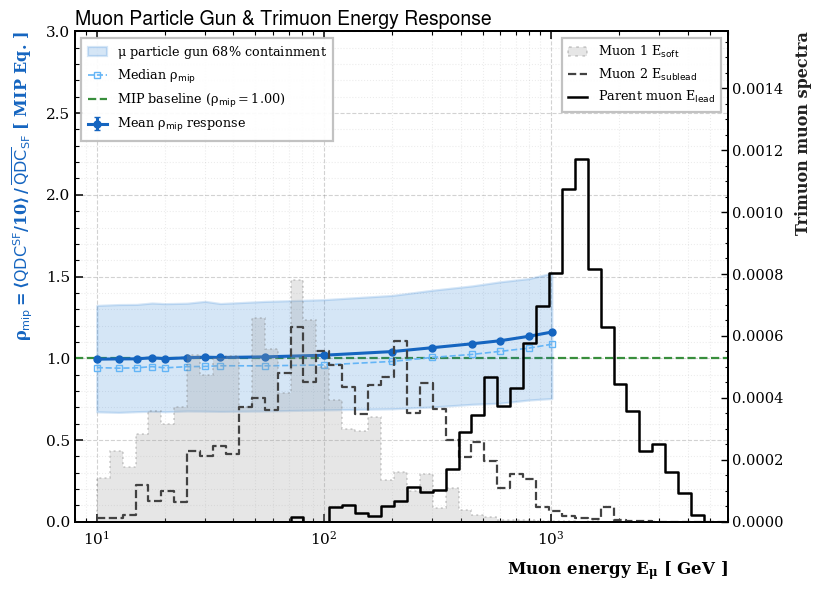

In [ ]:
import json
import ddfUtils.root as ddf_root
from ddfUtils.mpl_styling import add_label
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import uproot

# ==============================================================================
# 0. CONFIGURATION & METADATA
# ==============================================================================
ROOT_FILE = "/eos/user/i/idioniso/sndMuTri/out/pGun_response.root"

with uproot.open(ROOT_FILE) as f:
  meta = json.loads(str(f["metadata"])) if "metadata" in f else {}
  w_bar_sf = meta.get("w_bar_SF", 2.183)
  qdc_bar_sf = meta.get("qdc_bar_SF", 2.576)
  w_bar_ds = meta.get("w_bar_DS", 2.120)
  qdc_bar_ds = meta.get("qdc_bar_DS", 102.340)


def get_bin_probability(root_hist_path):
  """Extracts bin edges and normalizes bin heights such that each height = P(E in bin)."""
  x_centers, counts, edges, x_errs, y_errs = ddf_root.to_numpy(root_hist_path)
  total_weight = np.sum(counts)
  prob_per_bin = counts / total_weight if total_weight > 0 else counts
  return edges, prob_per_bin / 100.0


# Config dictionary for all 8 response variables
CONFIGS = {
    # ----------------- SciFi Variables -----------------
    ("scifi", "hits_plane"): {
        "ylabel": r"$\langle N_{\mathrm{hits}}^{\mathrm{SF}} / 10 \rangle$",
        "mean_label": r"Mean activated channels $\langle N_{\mathrm{hits}}^{\mathrm{SF}} / 10 \rangle$",
        "med_label": r"Median channels / plane",
        "baseline_val": w_bar_sf,
        "baseline_label": rf"SciFi MIP baseline ($\bar{{w}}_{{\mathrm{{SF}}}} = {w_bar_sf:.2f}$)",
        "xlim": (8.0, 6000.0),
        "ylim": (1.0, 5.5),
        "color": "#1565C0",
        "med_color": "#64B5F6",
        "band_color": "#1976D2",
    },
    ("scifi", "qdc_plane"): {
        "ylabel": r"$\langle \mathrm{QDC}^{\mathrm{SF}} / 10 \rangle$ [ ADC / Plane ]",
        "mean_label": r"Mean SciFi QDC $\langle \mathrm{QDC}^{\mathrm{SF}} / 10 \rangle$",
        "med_label": r"Median SciFi QDC / plane",
        "baseline_val": qdc_bar_sf,
        "baseline_label": rf"SciFi MIP baseline ($\overline{{\mathrm{{QDC}}}}_{{\mathrm{{SF}}}} = {qdc_bar_sf:.2f}$)",
        "xlim": (8.0, 6000.0),
        "ylim": (0.0, 8.0),
        "color": "#1565C0",
        "med_color": "#64B5F6",
        "band_color": "#1976D2",
    },
    ("scifi", "emip"): {
        "ylabel": r"$\varepsilon_{\mathrm{mip}}",
        "mean_label": r"Mean $\varepsilon_{\mathrm{mip}}$ response",
        "med_label": r"Median $\varepsilon_{\mathrm{mip}}$",
        "baseline_val": 1.00,
        "baseline_label": r"MIP baseline ($\varepsilon_{\mathrm{mip}} = 1.00$)",
        "xlim": (8.0, 6000.0),
        "ylim": (0.0, 3.0),
        "color": "#1565C0",
        "med_color": "#64B5F6",
        "band_color": "#1976D2",
    },
    ("scifi", "rhomip"): {
        "ylabel": r"$\rho_{\mathrm{mip}}",
        "mean_label": r"Mean $\rho_{\mathrm{mip}}$ response",
        "med_label": r"Median $\rho_{\mathrm{mip}}$",
        "baseline_val": 1.00,
        "baseline_label": r"MIP baseline ($\rho_{\mathrm{mip}} = 1.00$)",
        "xlim": (8.0, 6000.0),
        "ylim": (0.0, 3.0),
        "color": "#1565C0",
        "med_color": "#64B5F6",
        "band_color": "#1976D2",
    },
    # ----------------- Downstream (DS) Variables -----------------
    ("DS", "hits_plane"): {
        "ylabel": r"$\langle N_{\mathrm{hits}}^{\mathrm{DS}} / 10 \rangle$",
        "mean_label": r"Mean activated channels $\langle N_{\mathrm{hits}}^{\mathrm{DS}} / 10 \rangle$",
        "med_label": r"Median channels / plane",
        "baseline_val": w_bar_ds,
        "baseline_label": rf"DS MIP baseline ($\bar{{w}}_{{\mathrm{{DS}}}} = {w_bar_ds:.2f}$)",
        "xlim": (8.0, 6000.0),
        "ylim": (1.0, 5.5),
        "color": "#E65100",
        "med_color": "#FFB74D",
        "band_color": "#FB8C00",
    },
    ("DS", "qdc_plane"): {
        "ylabel": r"$\langle \mathrm{QDC}^{\mathrm{DS}} / 10 \rangle$",
        "mean_label": r"Mean DS QDC $\langle \mathrm{QDC}^{\mathrm{DS}} / 10 \rangle$",
        "med_label": r"Median DS QDC / plane",
        "baseline_val": qdc_bar_ds,
        "baseline_label": rf"DS MIP baseline ($\overline{{\mathrm{{QDC}}}}_{{\mathrm{{DS}}}} = {qdc_bar_ds:.1f}$)",
        "xlim": (8.0, 6000.0),
        "ylim": (0.0, 250.0),
        "color": "#E65100",
        "med_color": "#FFB74D",
        "band_color": "#FB8C00",
    },
    ("DS", "emip"): {
        "ylabel": r"$\varepsilon_{\mathrm{mip}}^{\mathrm{DS}}",
        "mean_label": r"Mean $\varepsilon_{\mathrm{mip}}^{\mathrm{DS}}$ response",
        "med_label": r"Median $\varepsilon_{\mathrm{mip}}^{\mathrm{DS}}$",
        "baseline_val": 1.00,
        "baseline_label": r"MIP baseline ($\varepsilon_{\mathrm{mip}}^{\mathrm{DS}} = 1.00$)",
        "xlim": (8.0, 6000.0),
        "ylim": (0.0, 3.0),
        "color": "#E65100",
        "med_color": "#FFB74D",
        "band_color": "#FB8C00",
    },
    ("DS", "rhomip"): {
        "ylabel": r"$\rho_{\mathrm{mip}}^{\mathrm{DS}}",
        "mean_label": r"Mean $\rho_{\mathrm{mip}}^{\mathrm{DS}}$ response",
        "med_label": r"Median $\rho_{\mathrm{mip}}^{\mathrm{DS}}$",
        "baseline_val": 1.00,
        "baseline_label": r"MIP baseline ($\rho_{\mathrm{mip}}^{\mathrm{DS}} = 1.00$)",
        "xlim": (8.0, 6000.0),
        "ylim": (0.0, 3.0),
        "color": "#E65100",
        "med_color": "#FFB74D",
        "band_color": "#FB8C00",
    },
}


# ==============================================================================
# 1. GENERAL PLOTTING FUNCTION
# ==============================================================================
def plot_response_variable(
    detector="scifi",
    var="rhomip",
    xlim=None,
    ylim=None,
    save_path=None,
    show=True,
):
  """Plots particle gun response vs trimuon muon energy spectra for any of the 8 variables."""
  cfg = CONFIGS[(detector, var)]

  # Graph paths in ROOT
  gr_mean_path = f"{ROOT_FILE}:{detector}/gr_mean_{var}"
  gr_band_path = f"{ROOT_FILE}:{detector}/gr_band_{var}"
  gr_med_path = f"{ROOT_FILE}:{detector}/gr_median_{var}"

  df_mean = ddf_root.to_pandas(gr_mean_path)
  df_band = ddf_root.to_pandas(gr_band_path)
  df_med = ddf_root.to_pandas(gr_med_path)

  # Read Trident Spectra
  edges_soft, prob_soft = get_bin_probability(
      f"{ROOT_FILE}:trimuon_mc/h_e_mu1"
  )
  edges_sub, prob_sub = get_bin_probability(
      f"{ROOT_FILE}:trimuon_mc/h_e_mu2"
  )
  edges_lead, prob_lead = get_bin_probability(
      f"{ROOT_FILE}:trimuon_mc/h_e_lead"
  )

  fig, ax = plt.subplots(figsize=(8.5, 6.2))
  ax_twin = ax.twinx()

  # 1. Right Axis: Trident Muon Energy Spectra
  ax_twin.fill_between(
      edges_soft[:-1],
      prob_soft,
      step="post",
      facecolor="#9E9E9E",
      alpha=0.25,
      edgecolor="#616161",
      linestyle=":",
      lw=1.4,
      label=r"Muon 1 $E_{\mathrm{soft}}$",
      zorder=1,
  )
  ax_twin.step(
      edges_sub[:-1],
      prob_sub,
      where="post",
      color="#424242",
      linestyle="--",
      lw=1.6,
      label=r"Muon 2 $E_{\mathrm{sublead}}$",
      zorder=2,
  )
  ax_twin.step(
      edges_lead[:-1],
      prob_lead,
      where="post",
      color="black",
      linestyle="-",
      lw=1.8,
      label=r"Parent muon $E_{\mathrm{lead}}$",
      zorder=3,
  )

  max_prob = max(prob_soft.max(), prob_sub.max(), prob_lead.max())
  ax_twin.set_ylabel(
      r"Trimuon muon spectra",
      fontweight="bold",
      color="#212121",
      fontsize=11.5,
      labelpad=8,
  )
  ax_twin.set_ylim(0, max_prob * 1.35)
  ax_twin.yaxis.set_minor_locator(ticker.AutoMinorLocator())
  ax_twin.tick_params(axis="y", labelsize=10.5, length=5, width=1.0)
  ax_twin.tick_params(axis="y", which="minor", length=2.5, width=0.8)

  # 2. Left Axis: Particle Gun Response Graphs
  # 68% Containment Shaded Band
  ax.fill_between(
      df_band["x"],
      df_band["y"] - df_band["eyl"],
      df_band["y"] + df_band["eyh"],
      color=cfg["band_color"],
      alpha=0.18,
      label=r"$\mu$ particle gun $68\%$ containment",
      zorder=4,
  )
  # Median Line
  ax.plot(
      df_med["x"],
      df_med["y"],
      "s--",
      color=cfg["med_color"],
      mfc="none",
      ms=4.0,
      lw=1.2,
      label=cfg["med_label"],
      zorder=5,
  )
  # Mean Points with Errors
  ax.errorbar(
      df_mean["x"],
      df_mean["y"],
      yerr=df_mean["ey"],
      fmt="o-",
      color=cfg["color"],
      ecolor=cfg["color"],
      lw=2.2,
      ms=5.0,
      capsize=2.5,
      label=cfg["mean_label"],
      zorder=6,
  )
  # MIP Baseline Horizontal Reference
  ax.axhline(
      cfg["baseline_val"],
      color="#388E3C",
      linestyle="--",
      lw=1.6,
      label=cfg["baseline_label"],
      zorder=3,
  )

  # Axes limits & styling
  ax.set_xscale("log")
  ax.set_xlim(xlim if xlim is not None else cfg["xlim"])
  ax.set_ylim(ylim if ylim is not None else cfg["ylim"])

  ax.set_xlabel(
      r"Muon energy $E_{\mu}$ [ GeV ]",
      fontweight="bold",
      fontsize=12,
      labelpad=8,
  )
  ax.set_ylabel(
      cfg["ylabel"],
      fontweight="bold",
      color=cfg["color"],
      fontsize=11.5,
      labelpad=8,
  )

  # Grid & Ticks
  ax.grid(True, which="major", linestyle="--", alpha=0.35, color="gray", zorder=1)
  ax.grid(True, which="minor", linestyle=":", alpha=0.15, color="gray", zorder=1)
  ax.tick_params(
      axis="both",
      which="major",
      direction="in",
      top=True,
      labelsize=11,
      length=6,
      width=1.1,
  )
  ax.tick_params(
      axis="both",
      which="minor",
      direction="in",
      top=True,
      labelsize=9,
      length=3,
      width=0.8,
  )

  ax.legend(
      loc="upper left",
      frameon=True,
      framealpha=0.92,
      edgecolor="#BDBDBD",
      facecolor="white",
      fontsize=9.2,
  )
  ax_twin.legend(
      loc="upper right",
      frameon=True,
      framealpha=0.92,
      edgecolor="#BDBDBD",
      facecolor="white",
      fontsize=9.2,
  )

  add_label(
      loc="top-left",
      supp_loc="top-right",
      mainText="",
      extraText="Muon Particle Gun Trimuon Simulations",
      suppText=r"",
      com=None,
      lumi=None,
      ax=ax,
  )

  plt.tight_layout()
  if save_path:
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
  if show:
    plt.show()
  plt.close(fig)

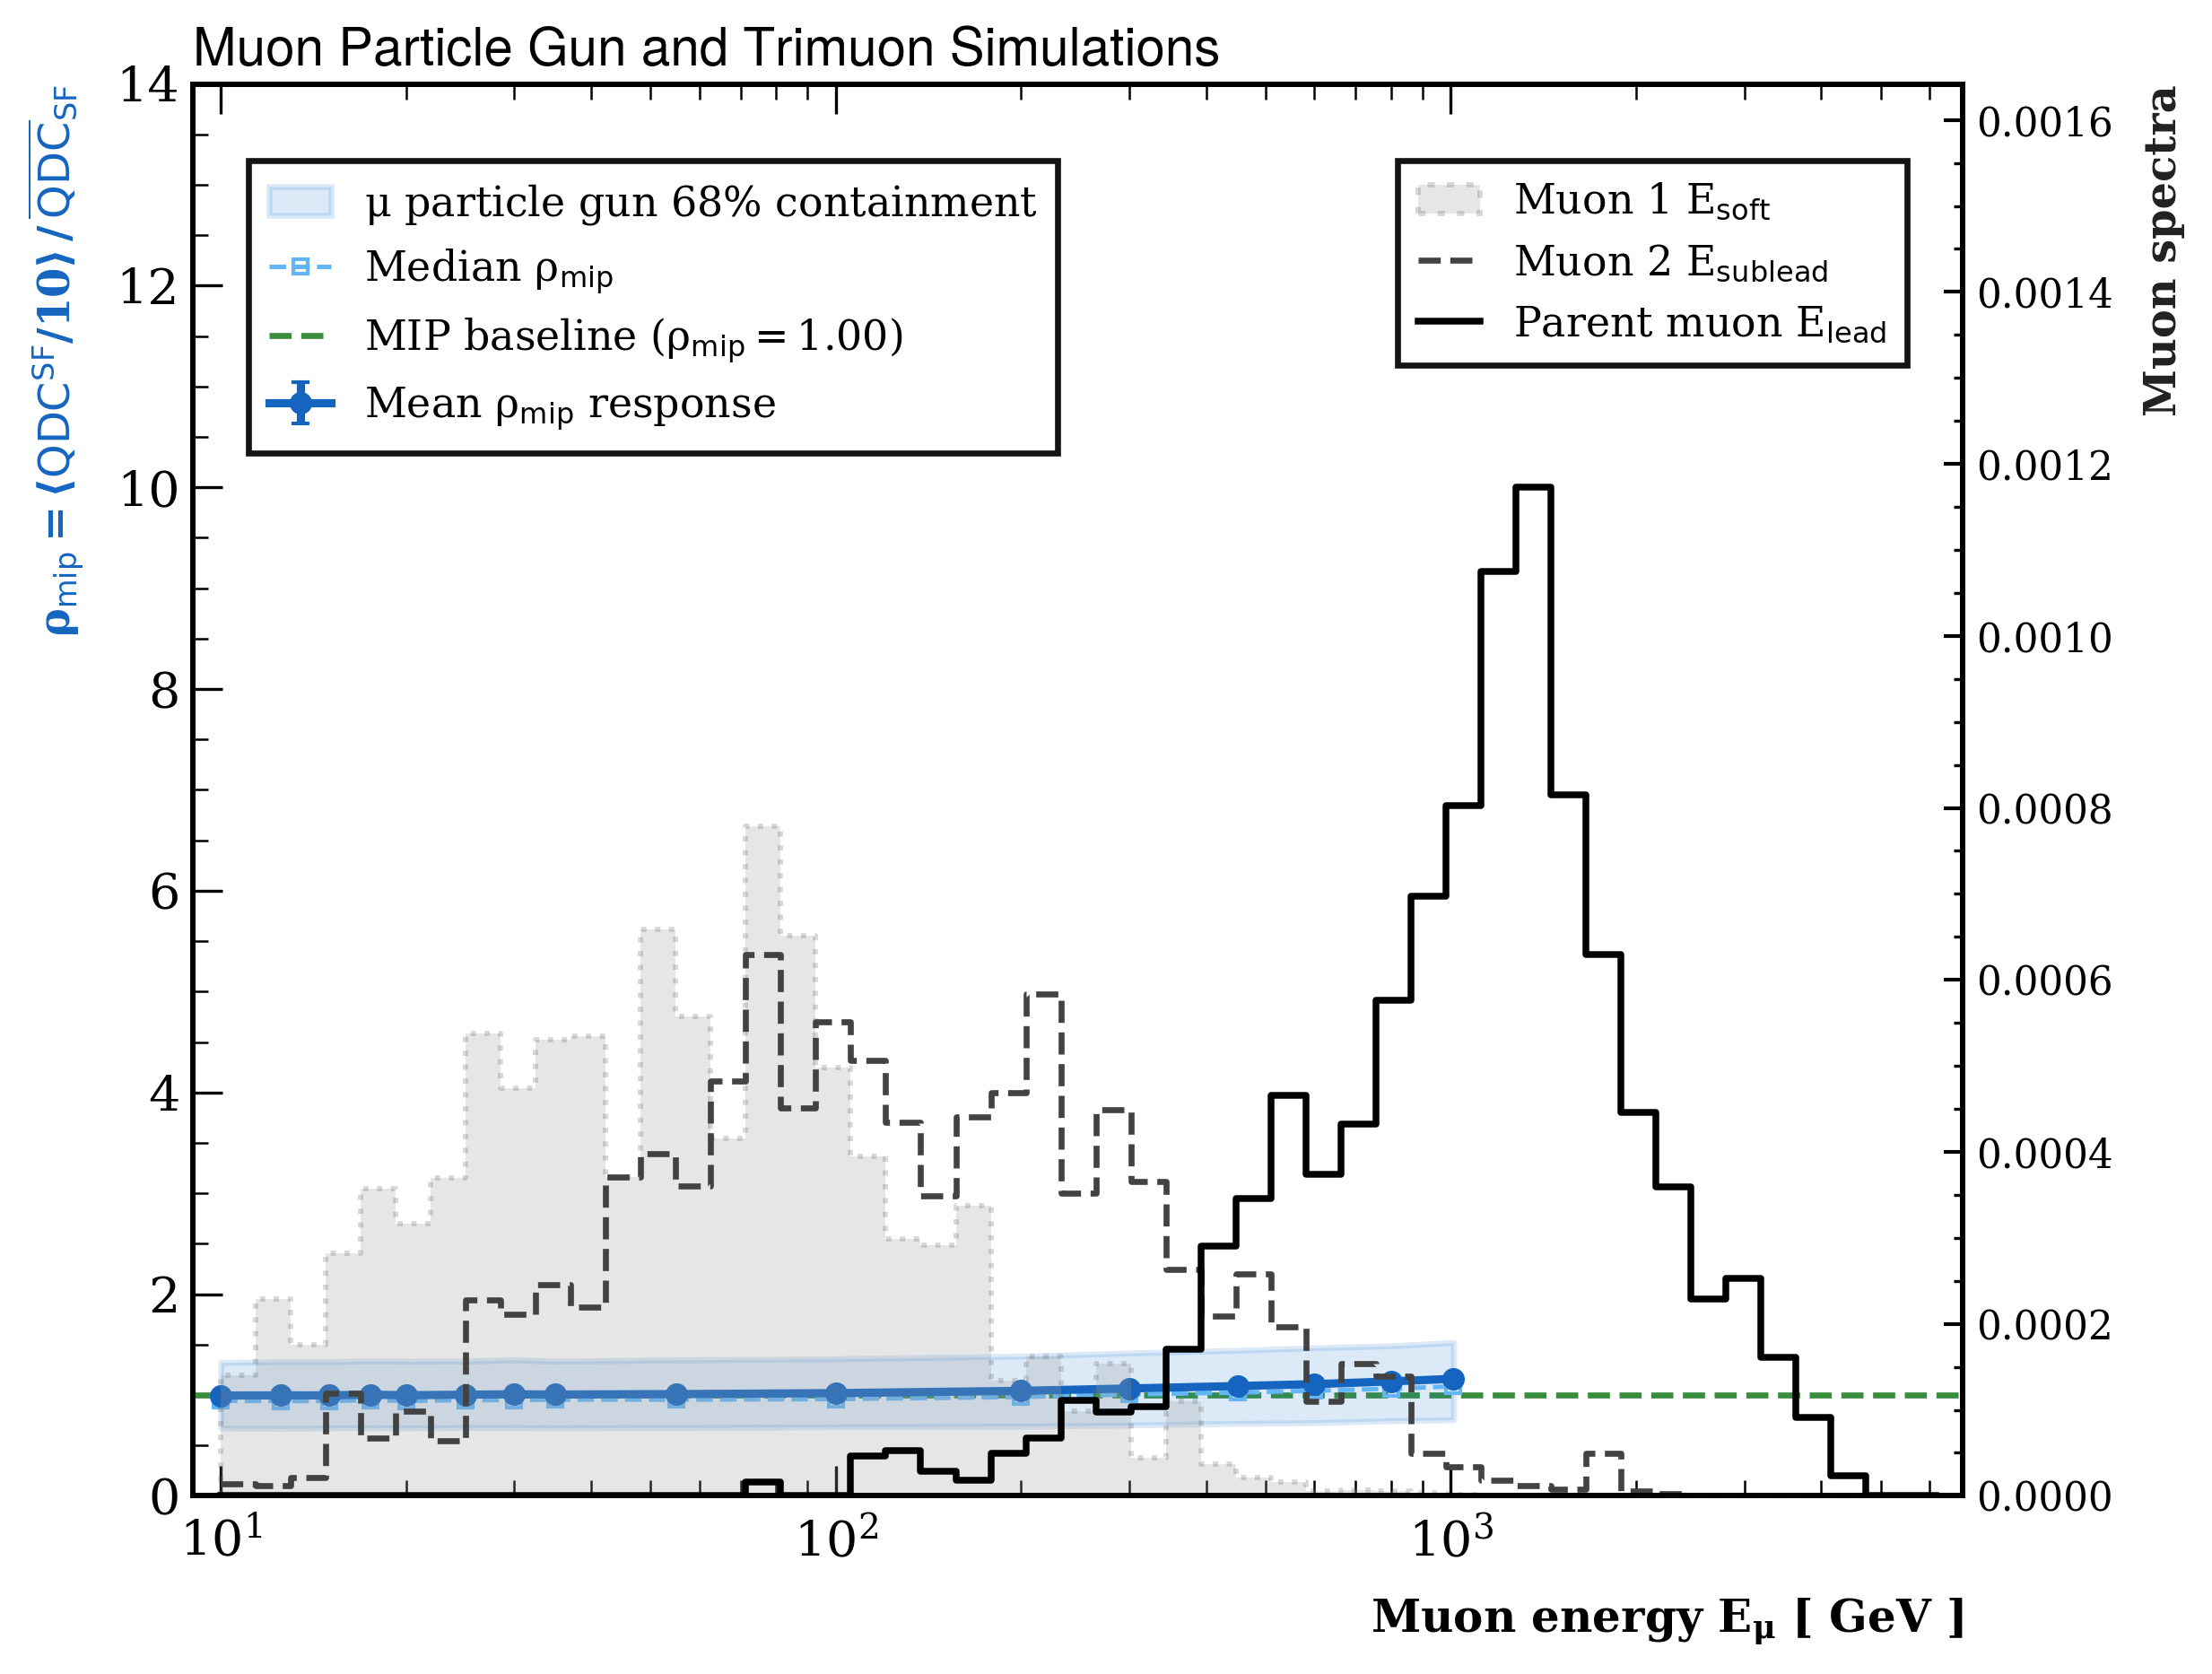

In [76]:
plot_response_variable(detector="scifi", var="rhomip")

In [ ]:
TRACKING_COLS = [
    "n_lines_sf_xz", "n_lines_sf_yz", "n_lines_ds_xz", "n_lines_ds_yz",
    "xz_sf_m1", "xz_sf_c1", "yz_sf_m1", "yz_sf_c1",
    "xz_sf_m2", "xz_sf_c2", "yz_sf_m2", "yz_sf_c2",
    "xz_sf_m3", "xz_sf_c3", "yz_sf_m3", "yz_sf_c3",
    "xz_ds_m1", "xz_ds_c1", "yz_ds_m1", "yz_ds_c1",
    "xz_ds_m2", "xz_ds_c2", "yz_ds_m2", "yz_ds_c2",
    "xz_ds_m3", "xz_ds_c3", "yz_ds_m3", "yz_ds_c3"
]

KINEMATIC_COLS = ["is_signal", "region_type", "mc_weight", "p_mu_in", "p_mu_minus", "p_mu_plus"]

In [ ]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ROOT
from scipy import stats

ROOT.gROOT.SetBatch(True)

# ==============================================================================
# 1. DATA EXTRACTION
# ==============================================================================
PGUN_DIR = Path("/eos/user/i/idioniso/1_Data/Monte_Carlo/pGun/muons")
sample_energies = ["10.GeV", "35.GeV", "100.GeV", "300.GeV", "800.GeV"]
colors = {
    "10.GeV": "#1E88E5",
    "35.GeV": "#43A047",
    "100.GeV": "#FB8C00",
    "300.GeV": "#E53935",
    "800.GeV": "#8E24AA",
}

data_records = []

for edir in sample_energies:
    digi_file = PGUN_DIR / edir / "sndLHC.PG_13-TGeant4_digCPP.root"
    if not digi_file.exists():
        continue

    energy_val = float(edir.replace(".GeV", ""))
    f = ROOT.TFile.Open(str(digi_file))
    if not f or f.IsZombie():
        continue

    tree = f.Get("cbmsim")
    if not tree:
        f.Close()
        continue

    n_entries = min(800, tree.GetEntries())
    for i in range(n_entries):
        tree.GetEntry(i)
        valid_signals = [
            h.GetSignal() for h in tree.Digi_ScifiHits if h.isValid()
        ]
        n_sf = len(valid_signals)
        if n_sf >= 5:
            hits_per_plane = n_sf / 10.0
            qdc_per_plane = sum(valid_signals) / 10.0
            data_records.append({
                "energy": energy_val,
                "energy_str": edir,
                "hits_plane": hits_per_plane,
                "qdc_plane": qdc_per_plane,
            })
    f.Close()

df_corr = pd.DataFrame(data_records)

# ==============================================================================
# 2. STATISTICAL CORRELATION METRICS
# ==============================================================================
x_hits = df_corr["hits_plane"].to_numpy()
y_qdc = df_corr["qdc_plane"].to_numpy()

r_pearson, p_pearson = stats.pearsonr(x_hits, y_qdc)
r_spearman, p_spearman = stats.spearmanr(x_hits, y_qdc)
slope, intercept, r_val, p_val, std_err = stats.linregress(x_hits, y_qdc)

df_corr["hit_bin"] = np.round(df_corr["hits_plane"] * 2) / 2.0  # 0.5-width bins
prof = (
    df_corr.groupby("hit_bin")["qdc_plane"]
    .agg(mean="mean", sem=lambda x: np.std(x) / np.sqrt(len(x)), count="count")
    .reset_index()
)
prof = prof[prof["count"] >= 10]

In [ ]:
x_hits = df_corr["hits_plane"].to_numpy()
y_qdc = df_corr["qdc_plane"].to_numpy()

r_pearson, p_pearson = stats.pearsonr(x_hits, y_qdc)
r_spearman, p_spearman = stats.spearmanr(x_hits, y_qdc)

In [ ]:
BIN_WIDTH = 0.5
df_corr["hit_bin"] = np.round(df_corr["hits_plane"] / BIN_WIDTH) * BIN_WIDTH

prof = (
    df_corr.groupby("hit_bin")["qdc_plane"]
    .agg(
        mean="mean",
        median="median",
        q16=lambda x: float(np.percentile(x, 16)),
        q84=lambda x: float(np.percentile(x, 84)),
        sem=lambda x: float(np.std(x, ddof=1) / np.sqrt(len(x)))
        if len(x) > 1
        else 1.0,
        count="count",
    )
    .reset_index()
)


prof = prof[prof["count"] >= 10].copy()

# Asymmetric 68% containment vertical errors [lower, upper]
yerr_asym = [
    np.maximum(0, (prof["mean"] - prof["q16"]).to_numpy()),
    np.maximum(0, (prof["q84"] - prof["mean"]).to_numpy()),
]

# Horizontal bin-width errors (half bin width = 0.25)
xerr_bins = BIN_WIDTH / 2.0

# Weighted linear fit on profile points (weighted by 1 / SEM)
weights = 1.0 / np.where(prof["sem"] > 0, prof["sem"], 1.0)
slope, intercept = np.polyfit(
    prof["hit_bin"].to_numpy(), prof["mean"].to_numpy(), deg=1, w=weights
)

# ==============================================================================
# 2. PLOTTING
# ==============================================================================
fig, ax = plt.subplots(figsize=(8.5, 6.5))

# 2a. Background Scatter Points per Energy Sample
for edir in sample_energies:
    sub = df_corr[df_corr["energy_str"] == edir]
    if sub.empty:
        continue
    ax.scatter(
        sub["hits_plane"],
        sub["qdc_plane"],
        color=colors[edir],
        label=rf"$E_\mu = {sub['energy'].iloc[0]:.0f}\ \mathrm{{GeV}}$",
        alpha=0.30,
        s=20,
        edgecolors="none",
        zorder=2,
    )

# 2b. Weighted Linear Fit Line
x_line = np.linspace(0.8, 15.0, 100)
ax.plot(
    x_line,
    slope * x_line + intercept,
    color="darkred",
    linestyle="--",
    lw=2.2,
    zorder=4,
    label=(
        rf"Profile linear fit ($\mathrm{{slope}} = {slope:.2f}$)"
    ),
)

ax.errorbar(
    prof["hit_bin"],
    prof["mean"],
    xerr=xerr_bins,
    yerr=yerr_asym,
    fmt="o",
    color="black",
    ecolor="black",
    elinewidth=1.6,
    capsize=3.0,
    capthick=1.4,
    markersize=5.5,
    zorder=5,
    label=r"Profile $\langle \mathrm{QDC} \rangle$",
)

ax.set_xlabel(
    r"$\langle N_{\mathrm{hits}}^{\mathrm{SF}} / 10 \rangle$",
    fontweight="bold",
    fontsize=12,
    labelpad=8,
)
ax.set_ylabel(
    r"$\langle \mathrm{QDC}^{\mathrm{SF}} / 10 \rangle$",
    fontweight="bold",
    fontsize=12,
    labelpad=8,
)
ax.set_xlim(0.5, 15.5)
ax.set_ylim(0.0, 24.0)

# ax.grid(True, which="major", linestyle="--", alpha=0.4, color="gray", zorder=1)
# ax.minorticks_on()
# ax.grid(True, which="minor", linestyle=":", alpha=0.2, color="gray", zorder=1)
# ax.tick_params(axis="both", which="major", labelsize=11, length=6, width=1.2)
# ax.tick_params(axis="both", which="minor", labelsize=9, length=3, width=0.8)

# Legend
ax.legend(
    loc="upper left",
    frameon=True,
    framealpha=0.8,
    fontsize=12.0,
    title=(
        rf"($r = {r_pearson:.3f},\ \rho = {r_spearman:.3f}$)"
    ),
    title_fontsize=11.0,
)

add_label(
    loc="top-left",
    supp_loc="top-right",
    mainText="", extraText="Particle Gun Muon Simulation",
    style="formal",
    com=None,
    lumi=None,
    ax=ax,
)

plt.tight_layout()
plt.show()
plt.close()

In [ ]:
    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    ax1_twin = ax.twinx()
    
    # ==============================================================================
    # 1. TRIDENT MUON SPECTRA (RIGHT AXIS)
    # ==============================================================================
    edges_soft, prob_soft = get_bin_probability(f"{ROOT_FILE}:trimuon_mc/h_e_mu1")
    edges_sub, prob_sub = get_bin_probability(f"{ROOT_FILE}:trimuon_mc/h_e_mu2")
    edges_lead, prob_lead = get_bin_probability(f"{ROOT_FILE}:trimuon_mc/h_e_lead")
    
    # Softest Muon
    ax1_twin.fill_between(
        edges_soft[:-1],
        prob_soft,
        step="post",
        facecolor="#9E9E9E",
        alpha=0.25,
        edgecolor="#616161",
        linestyle=":",
        lw=1.4,
        label=r"Muon 1 $E_{\mathrm{soft}}$",
        zorder=1,
    )
    
    # Sub-Leading Muon
    ax1_twin.step(
        edges_sub[:-1],
        prob_sub,
        where="post",
        color="#424242",
        linestyle="--",
        lw=1.6,
        label=r"Muon 2 $E_{\mathrm{sublead}}$",
        zorder=2,
    )
    
    # Leading Muon
    ax1_twin.step(
        edges_lead[:-1],
        prob_lead,
        where="post",
        color="black",
        linestyle="-",
        lw=1.8,
        label=r"Parent muon $E_{\mathrm{lead}}$",
        zorder=3,
    )
    
    max_prob = max(prob_soft.max(), prob_sub.max(), prob_lead.max())
    ax1_twin.set_ylabel(
        r"Muon spectra",
        fontweight="bold",
        color="#212121",
        fontsize=11.5,
        labelpad=8,
    )
    ax1_twin.set_ylim(0, max_prob * 1.40)
    ax1_twin.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax1_twin.tick_params(axis="y", labelsize=10.5, length=5, width=1.0)
    ax1_twin.tick_params(axis="y", which="minor", length=2.5, width=0.8)
    
    # ==============================================================================
    # 2. MIP-EQUIVALENCE RESPONSE (LEFT AXIS)
    # ==============================================================================
    df_emip = ddf_root.to_pandas(f"{ROOT_FILE}:scifi/gr_mean_emip")
    df_emip_band = ddf_root.to_pandas(f"{ROOT_FILE}:scifi/gr_band_emip")
    df_emip_med = ddf_root.to_pandas(f"{ROOT_FILE}:scifi/gr_median_emip")
    
    # 68% Containment Band
    ax.fill_between(
        df_emip_band["x"],
        df_emip_band["y"] - df_emip_band["eyl"],
        df_emip_band["y"] + df_emip_band["eyh"],
        color="#80CBC4",
        alpha=0.25,
        label=r"$\mu$ particle gun $68\%$ containment",
        zorder=4,
    )
    
    # Median MIP-Equivalence
    ax.plot(
        df_emip_med["x"],
        df_emip_med["y"],
        "s--",
        color="#4DB6AC",
        mfc="none",
        ms=4.0,
        lw=1.2,
        label=r"Median MIP equivalent",
        zorder=5,
    )
    
    # Mean MIP-Equivalence with SEM error bars
    ax.errorbar(
        df_emip["x"],
        df_emip["y"],
        yerr=df_emip["ey"],
        fmt="o-",
        color="#004D40",
        ecolor="#004D40",
        lw=2.2,
        ms=5.0,
        capsize=2.5,
        label=r"Mean MIP equivalent $\langle \varepsilon_{\mathrm{mip}} \rangle$",
        zorder=6,
    )
    
    # Single-MIP Baseline Reference Line (e_mip = 1.00)
    ax.axhline(
        1.00,
        color="#FF7043",
        linestyle="--",
        lw=1.6,
        label=r"Single-MIP baseline ($\varepsilon_{\mathrm{mip}} = 1.00$)",
        zorder=3,
    )
    
    # Axis Configuration
    ax.set_xscale("log")
    ax.set_xlim(9, 6800)
    ax.set_ylim(0.4, 5.2)
    ax.set_xlabel(
        r"Muon energy $E_{\mu}$ [ GeV ]", fontweight="bold", fontsize=12, labelpad=8
    )
    ax.set_ylabel(
        r"$\varepsilon_{\mathrm{mip}}$",
        fontweight="bold",
        color="#004D40",
        fontsize=13,
        labelpad=8,
    )
    
    # Ticks and Grid
    ax.grid(True, which="major", linestyle="--", alpha=0.4, color="gray", zorder=0)
    ax.minorticks_on()
    ax.grid(True, which="minor", linestyle=":", alpha=0.2, color="gray", zorder=0)
    ax.tick_params(axis="both", which="major", labelsize=11, length=6, width=1.2)
    ax.tick_params(axis="both", which="minor", labelsize=9, length=3, width=0.8)
    
    # Legends
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(0.02, 0.96),
        frameon=True,
        framealpha=0.92,
        fontsize=12.0,
        title_fontsize=9.5,
    )
    ax1_twin.legend(
        loc="upper right",
        bbox_to_anchor=(0.98, 0.96),
        frameon=True,
        framealpha=0.92,
        fontsize=12.0,
        title_fontsize=9.5,
    )

    # Header
    add_label(
        loc="top-left",
        supp_loc="top-right",
        mainText="",
        extraText="Muon Particle Gun and Trimuon Simulations",
        suppText=r"",
        com=None,
        lumi=None,
        ax=ax,
    )

    plt.tight_layout()
    plt.show()
    plt.close(fig)

NameError: name 'get_bin_probability' is not defined

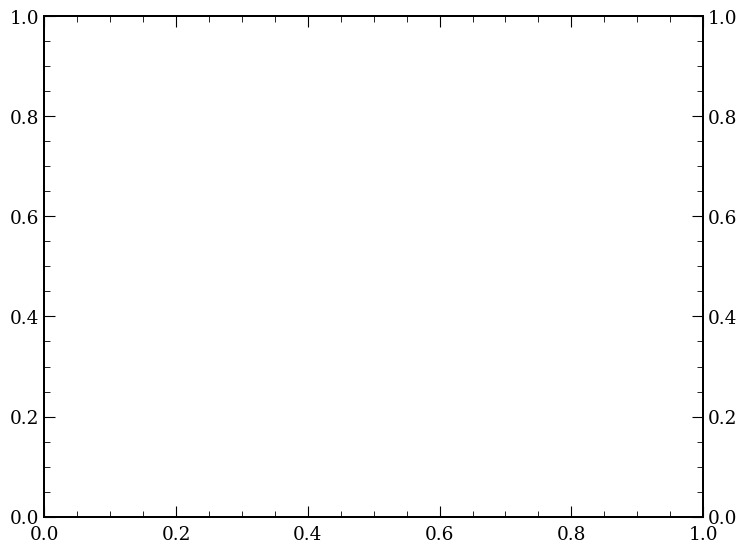

In [70]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))
ax1_twin = ax.twinx()

edges_soft, prob_soft = get_bin_probability(f"{ROOT_FILE}:trimuon_mc/h_e_mu1")
edges_sub, prob_sub = get_bin_probability(f"{ROOT_FILE}:trimuon_mc/h_e_mu2")
edges_lead, prob_lead = get_bin_probability(f"{ROOT_FILE}:trimuon_mc/h_e_lead")

ax1_twin.fill_between(
    edges_soft[:-1],
    prob_soft,
    step="post",
    facecolor="#9E9E9E",
    alpha=0.25,
    edgecolor="#616161",
    linestyle=":",
    lw=1.4,
    label=r"Muon 1 $E_{\mathrm{soft}}$",
    zorder=1,
)

ax1_twin.step(
    edges_sub[:-1],
    prob_sub,
    where="post",
    color="#424242",
    linestyle="--",
    lw=1.6,
    label=r"Muon 2 $E_{\mathrm{sublead}}$",
    zorder=2,
)

ax1_twin.step(
    edges_lead[:-1],
    prob_lead,
    where="post",
    color="black",
    linestyle="-",
    lw=1.8,
    label=r"Parent muon $E_{\mathrm{lead}}$",
    zorder=3,
)

max_prob = max(prob_soft.max(), prob_sub.max(), prob_lead.max())
ax1_twin.set_ylabel(
    r"Muon spectra",
    fontweight="bold",
    color="#212121",
    fontsize=11.5,
    labelpad=8,
)
ax1_twin.set_ylim(0, max_prob * 1.40)
ax1_twin.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax1_twin.tick_params(axis="y", labelsize=10.5, length=5, width=1.0)
ax1_twin.tick_params(axis="y", which="minor", length=2.5, width=0.8)


df_rhomip = ddf_root.to_pandas(f"{ROOT_FILE}:scifi/gr_mean_rhomip")
df_rhomip_band = ddf_root.to_pandas(f"{ROOT_FILE}:scifi/gr_band_rhomip")
df_rhomip_med = ddf_root.to_pandas(f"{ROOT_FILE}:scifi/gr_median_rhomip")

ax.fill_between(
    df_rhomip_band["x"],
    df_rhomip_band["y"] - df_rhomip_band["eyl"],
    df_rhomip_band["y"] + df_rhomip_band["eyh"],
    color="#CE93D8",
    alpha=0.25,
    label=r"$\mu$ particle gun $68\%$ containment",
    zorder=4,
)

ax.plot(
    df_rhomip_med["x"],
    df_rhomip_med["y"],
    "s--",
    color="#BA68C8",
    mfc="none",
    ms=4.0,
    lw=1.2,
    label=r"Median MIP charge density",
    zorder=5,
)

# Mean MIP Charge Density with SEM error bars
ax.errorbar(
    df_rhomip["x"],
    df_rhomip["y"],
    yerr=df_rhomip["ey"],
    fmt="o-",
    color="#4A148C",
    ecolor="#4A148C",
    lw=2.2,
    ms=5.0,
    capsize=2.5,
    label=r"Mean charge density $\langle \rho_{\mathrm{mip}} \rangle$",
    zorder=6,
)

ax.axhline(
    1.00,
    color="#8D6E63",
    linestyle="--",
    lw=1.6,
    label=r"MIP ionization standard ($\rho_{\mathrm{mip}} = 1.00$)",
    zorder=3,
)

# Axis Configuration
ax.set_xscale("log")
ax.set_xlim(9, 6800)
ax.set_ylim(0.45, 1.85)
ax.set_xlabel(
    r"Muon energy $E_{\mu}$ [ GeV ]", fontweight="bold", fontsize=12, labelpad=8
)
ax.set_ylabel(
    r"$\rho_{\mathrm{mip}}$",
    fontweight="bold",
    color="#4A148C",
    fontsize=13,
    labelpad=8,
)

# Ticks and Grid
ax.grid(True, which="major", linestyle="--", alpha=0.4, color="gray", zorder=0)
ax.minorticks_on()
ax.grid(True, which="minor", linestyle=":", alpha=0.2, color="gray", zorder=0)
ax.tick_params(axis="both", which="major", labelsize=11, length=6, width=1.2)
ax.tick_params(axis="both", which="minor", labelsize=9, length=3, width=0.8)

# Legends
ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.02, 0.96),
    frameon=True,
    framealpha=0.92,
    fontsize=12.0,
    title_fontsize=9.5,
)
ax1_twin.legend(
    loc="upper right",
    bbox_to_anchor=(0.98, 0.96),
    frameon=True,
    framealpha=0.92,
    fontsize=12.0,
    title_fontsize=9.5,
)

# Header
add_label(
    loc="top-left",
    supp_loc="top-right",
    mainText="",
    extraText="Muon Particle Gun and Trimuon Simulations",
    suppText=r"",
    com=None,
    lumi=None,
    ax=ax,
)

plt.tight_layout()
plt.show()
plt.close(fig)

In [ ]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

# ==============================================================================
# 1. PATHS, CONSTANTS & COLUMN DEFINITIONS
# ==============================================================================
MC_PATH = Path(
    "/eos/user/i/idioniso/sndMuTri/data/cutset8/trimuon_boost100/trimuon_digCPP_hough_cutset8.parquet"
)
DATA_PATH = Path(
    "/eos/user/i/idioniso/sndMuTri/data/cutset8/run_006640/sndsw_raw_cutset8_hough.parquet"
)
GAL_PATH = Path(
    "/eos/user/i/idioniso/sndMuTri/data/cutset8/gallery/mu3_search_hough_cutset8.parquet"
)

LUMI_FULL_6640 = 0.9915864253712848  # Full Run 6640 luminosity [fb^-1]
LUMI_MC_DATASET = 0.0250  # MC sample generated luminosity [fb^-1]

SCALE_DATA_TO_FULL = 1.0
SCALE_MC_TO_FULL = LUMI_FULL_6640 / LUMI_MC_DATASET  # ~39.66

W_BAR_SF = 2.13  # Average hits per plane for 1 MIP
QDC_BAR_SF = 2.48  # Average QDC per plane for 1 MIP

LOAD_COLS = [
    "n_lines_sf_xz",
    "n_lines_sf_yz",
    "n_lines_ds_xz",
    "n_lines_ds_yz",
    "xz_sf_m1",
    "xz_sf_c1",
    "yz_sf_m1",
    "yz_sf_c1",
    "xz_sf_m2",
    "xz_sf_c2",
    "yz_sf_m2",
    "yz_sf_c2",
    "xz_sf_m3",
    "xz_sf_c3",
    "yz_sf_m3",
    "yz_sf_c3",
    "xz_ds_m1",
    "xz_ds_c1",
    "yz_ds_m1",
    "yz_ds_c1",
    "xz_ds_m2",
    "xz_ds_c2",
    "yz_ds_m2",
    "yz_ds_c2",
    "xz_ds_m3",
    "xz_ds_c3",
    "yz_ds_m3",
    "yz_ds_c3",
    "scifi_nhits",
    "scifi_sum_qdc",
]


# ==============================================================================
# 2. SELECTION FUNCTION: [SF(3,1) | DS(3,1)] & (SF_nc & DS_nc)
# ==============================================================================
def check_nc(
    df: pd.DataFrame,
    prefix: str,
    proj: str,
    z_min: float,
    z_max: float,
    strict: bool = True,
) -> np.ndarray:
  n = df[f"n_lines_{prefix}_{proj}"].to_numpy()
  m1, c1 = (
      np.nan_to_num(df[f"{proj}_{prefix}_m1"].to_numpy()),
      np.nan_to_num(df[f"{proj}_{prefix}_c1"].to_numpy()),
  )
  m2, c2 = (
      np.nan_to_num(df[f"{proj}_{prefix}_m2"].to_numpy()),
      np.nan_to_num(df[f"{proj}_{prefix}_c2"].to_numpy()),
  )
  m3, c3 = (
      np.nan_to_num(df[f"{proj}_{prefix}_m3"].to_numpy()),
      np.nan_to_num(df[f"{proj}_{prefix}_c3"].to_numpy()),
  )

  no_cross_12 = (
      (m1 * z_min + c1 - (m2 * z_min + c2))
      * (m1 * z_max + c1 - (m2 * z_max + c2))
  ) > 0
  no_cross_13 = (
      (m1 * z_min + c1 - (m3 * z_min + c3))
      * (m1 * z_max + c1 - (m3 * z_max + c3))
  ) > 0
  no_cross_23 = (
      (m2 * z_min + c2 - (m3 * z_min + c3))
      * (m2 * z_max + c2 - (m3 * z_max + c3))
  ) > 0

  pass_3 = (n >= 3) & no_cross_12 & no_cross_13 & no_cross_23
  pass_2 = (n == 2) & no_cross_12
  return (pass_3 | pass_2) if strict else (pass_3 | pass_2 | (n <= 1))


def apply_selection(df: pd.DataFrame) -> pd.DataFrame:
  nx, ny = df["n_lines_sf_xz"].to_numpy(), df["n_lines_sf_yz"].to_numpy()
  nx_ds, ny_ds = df["n_lines_ds_xz"].to_numpy(), df["n_lines_ds_yz"].to_numpy()

  sf_3_1 = ((nx >= 3) & (ny >= 1)) | ((ny >= 3) & (nx >= 1))
  ds_3_1 = ((nx_ds >= 3) & (ny_ds >= 1)) | ((ny_ds >= 3) & (nx_ds >= 1))

  coll_sf = check_nc(df, "sf", "xz", 260.0, 355.0) | check_nc(
      df, "sf", "yz", 260.0, 355.0
  )
  coll_ds = check_nc(df, "ds", "xz", 460.0, 590.0) | check_nc(
      df, "ds", "yz", 460.0, 590.0
  )

  return df[(sf_3_1 | ds_3_1) & coll_sf & coll_ds].copy()


# ==============================================================================
# 3. LOAD DATASETS & FILTER
# ==============================================================================
# 1. MC Rock Trident Signal
mc_raw = pq.read_table(
    MC_PATH, columns=LOAD_COLS + ["is_signal", "region_type", "mc_weight"]
).to_pandas()
sig_mc = mc_raw[(mc_raw["is_signal"] == 1) & (mc_raw["region_type"] == 1)]
sel_mc = apply_selection(sig_mc)

# 2. Collision Data
data_raw = pq.read_table(DATA_PATH, columns=LOAD_COLS).to_pandas()
sel_data = apply_selection(data_raw)

# 3. Visual Gallery Candidates
if GAL_PATH.exists():
  gal_raw = pq.read_table(GAL_PATH, columns=LOAD_COLS).to_pandas()
  sel_gal = apply_selection(gal_raw)
else:
  sel_gal = pd.DataFrame()

# ==============================================================================
# 4. COMPUTE EPSILON_MIP
# ==============================================================================
eps_mc_sel = 0.5 * (
    (sel_mc["scifi_nhits"].to_numpy() / 10.0) / W_BAR_SF
    + (sel_mc["scifi_sum_qdc"].to_numpy() / 10.0) / QDC_BAR_SF
)

eps_data_sel = 0.5 * (
    (sel_data["scifi_nhits"].to_numpy() / 10.0) / W_BAR_SF
    + (sel_data["scifi_sum_qdc"].to_numpy() / 10.0) / QDC_BAR_SF
)

if not sel_gal.empty and "scifi_nhits" in sel_gal.columns:
  eps_gal_sel = 0.5 * (
      (sel_gal["scifi_nhits"].to_numpy() / 10.0) / W_BAR_SF
      + (sel_gal["scifi_sum_qdc"].to_numpy() / 10.0) / QDC_BAR_SF
  )
else:
  eps_gal_sel = np.array([])

mc_weights_full = sel_mc["mc_weight"].to_numpy() * SCALE_MC_TO_FULL
n_mc_full_expected = mc_weights_full.sum()


In [33]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import ROOT
from scipy import stats

ROOT.gROOT.SetBatch(True)

# ==============================================================================
# 1. FILE PATHS & SELECTION CRITERIA
# ==============================================================================
MC_PATH = Path(
    "/eos/user/i/idioniso/sndMuTri/data/cutset8/trimuon_boost100/trimuon_digCPP_hough_cutset8.parquet"
)
DATA_PATH = Path(
    "/eos/user/i/idioniso/sndMuTri/data/cutset8/run_006640/sndsw_raw_cutset8_hough.parquet"
)

LUMI_FULL_6640 = 0.9915864253712848  # Target Run 6640 luminosity [fb^-1]
LUMI_MC_DATASET = 0.0250  # MC sample luminosity [fb^-1]
SCALE_MC_TO_FULL = LUMI_FULL_6640 / LUMI_MC_DATASET

LOAD_COLS = [
    "n_lines_sf_xz",
    "n_lines_sf_yz",
    "n_lines_ds_xz",
    "n_lines_ds_yz",
    "xz_sf_m1",
    "xz_sf_c1",
    "yz_sf_m1",
    "yz_sf_c1",
    "xz_sf_m2",
    "xz_sf_c2",
    "yz_sf_m2",
    "yz_sf_c2",
    "xz_sf_m3",
    "xz_sf_c3",
    "yz_sf_m3",
    "yz_sf_c3",
    "xz_ds_m1",
    "xz_ds_c1",
    "yz_ds_m1",
    "yz_ds_c1",
    "xz_ds_m2",
    "xz_ds_c2",
    "yz_ds_m2",
    "yz_ds_c2",
    "xz_ds_m3",
    "xz_ds_c3",
    "yz_ds_m3",
    "yz_ds_c3",
    "scifi_nhits",
    "scifi_sum_qdc",
]


def check_nc(
    df: pd.DataFrame,
    prefix: str,
    proj: str,
    z_min: float,
    z_max: float,
    strict: bool = True,
) -> np.ndarray:
  n = df[f"n_lines_{prefix}_{proj}"].to_numpy()
  m1, c1 = (
      np.nan_to_num(df[f"{proj}_{prefix}_m1"].to_numpy()),
      np.nan_to_num(df[f"{proj}_{prefix}_c1"].to_numpy()),
  )
  m2, c2 = (
      np.nan_to_num(df[f"{proj}_{prefix}_m2"].to_numpy()),
      np.nan_to_num(df[f"{proj}_{prefix}_c2"].to_numpy()),
  )
  m3, c3 = (
      np.nan_to_num(df[f"{proj}_{prefix}_m3"].to_numpy()),
      np.nan_to_num(df[f"{proj}_{prefix}_c3"].to_numpy()),
  )

  x1_min, x1_max = m1 * z_min + c1, m1 * z_max + c1
  x2_min, x2_max = m2 * z_min + c2, m2 * z_max + c2
  x3_min, x3_max = m3 * z_min + c3, m3 * z_max + c3

  no_cross_12 = ((x1_min - x2_min) * (x1_max - x2_max)) > 0
  no_cross_13 = ((x1_min - x3_min) * (x1_max - x3_max)) > 0
  no_cross_23 = ((x2_min - x3_min) * (x2_max - x3_max)) > 0

  pass_3 = (n >= 3) & no_cross_12 & no_cross_13 & no_cross_23
  pass_2 = (n == 2) & no_cross_12
  return (pass_3 | pass_2) if strict else (pass_3 | pass_2 | (n <= 1))


def apply_selection(df: pd.DataFrame) -> pd.DataFrame:
  nx, ny = df["n_lines_sf_xz"].to_numpy(), df["n_lines_sf_yz"].to_numpy()
  nx_ds, ny_ds = df["n_lines_ds_xz"].to_numpy(), df["n_lines_ds_yz"].to_numpy()

  sf_3_1 = ((nx >= 3) & (ny >= 1)) | ((ny >= 3) & (nx >= 1))
  ds_3_1 = ((nx_ds >= 3) & (ny_ds >= 1)) | ((ny_ds >= 3) & (nx_ds >= 1))
  mult_mask = sf_3_1 | ds_3_1

  coll_sf = check_nc(df, "sf", "xz", 260.0, 355.0) | check_nc(
      df, "sf", "yz", 260.0, 355.0
  )
  coll_ds = check_nc(df, "ds", "xz", 460.0, 590.0) | check_nc(
      df, "ds", "yz", 460.0, 590.0
  )
  return df[mult_mask & coll_sf & coll_ds].copy()


# ==============================================================================
# 2. LOAD & EXTRACT DATASETS
# ==============================================================================
print("[*] Loading MC and Collision Data...")
mc_df = pq.read_table(
    MC_PATH, columns=LOAD_COLS + ["is_signal", "region_type", "mc_weight"]
).to_pandas()
sig_mc = mc_df[(mc_df["is_signal"] == 1) & (mc_df["region_type"] == 1)]
bkg_mc = mc_df[mc_df["is_signal"] == 0]

sel_sig = apply_selection(sig_mc)
sel_bkg = apply_selection(bkg_mc)

data_df = pq.read_table(DATA_PATH, columns=LOAD_COLS).to_pandas()
sel_data = apply_selection(data_df)

print(
    f"    -> Surviving Signal MC: {len(sel_sig):,} | Non-Signal MC:"
    f" {len(sel_bkg):,} | Data: {len(sel_data):,}"
)

# Convert to hits/plane and QDC/plane
df_sig = pd.DataFrame({
    "hits_plane": sel_sig["scifi_nhits"].to_numpy() / 10.0,
    "qdc_plane": sel_sig["scifi_sum_qdc"].to_numpy() / 10.0,
})
df_bkg = pd.DataFrame({
    "hits_plane": sel_bkg["scifi_nhits"].to_numpy() / 10.0,
    "qdc_plane": sel_bkg["scifi_sum_qdc"].to_numpy() / 10.0,
})
df_data = pd.DataFrame({
    "hits_plane": sel_data["scifi_nhits"].to_numpy() / 10.0,
    "qdc_plane": sel_data["scifi_sum_qdc"].to_numpy() / 10.0,
})


# ==============================================================================
# 3. STATISTICAL CORRELATION & BINNED PROFILES
# ==============================================================================
def compute_profile(df: pd.DataFrame, bin_width: float = 0.5, min_count: int = 5):
  df_c = df.copy()
  df_c["hit_bin"] = np.round(df_c["hits_plane"] / bin_width) * bin_width
  prof = (
      df_c.groupby("hit_bin")["qdc_plane"]
      .agg(
          mean="mean",
          median="median",
          q16=lambda x: float(np.percentile(x, 16)),
          q84=lambda x: float(np.percentile(x, 84)),
          sem=lambda x: (
              float(np.std(x, ddof=1) / np.sqrt(len(x))) if len(x) > 1 else 1.0
          ),
          count="count",
      )
      .reset_index()
  )
  return prof[prof["count"] >= min_count].copy()


BIN_WIDTH = 0.5
prof_sig = compute_profile(df_sig, bin_width=BIN_WIDTH, min_count=10)
prof_data = compute_profile(df_data, bin_width=BIN_WIDTH, min_count=10)

# Correlation and weighted linear fits
r_pearson_sig, _ = stats.pearsonr(df_sig["hits_plane"], df_sig["qdc_plane"])
weights_sig = 1.0 / np.where(prof_sig["sem"] > 0, prof_sig["sem"], 1.0)
slope_sig, intercept_sig = np.polyfit(
    prof_sig["hit_bin"].to_numpy(),
    prof_sig["mean"].to_numpy(),
    deg=1,
    w=weights_sig,
)

r_pearson_data, _ = stats.pearsonr(df_data["hits_plane"], df_data["qdc_plane"])
weights_data = 1.0 / np.where(prof_data["sem"] > 0, prof_data["sem"], 1.0)
slope_data, intercept_data = np.polyfit(
    prof_data["hit_bin"].to_numpy(),
    prof_data["mean"].to_numpy(),
    deg=1,
    w=weights_data,
)


[*] Loading MC and Collision Data...
    -> Surviving Signal MC: 5,894 | Non-Signal MC: 311 | Data: 1,385


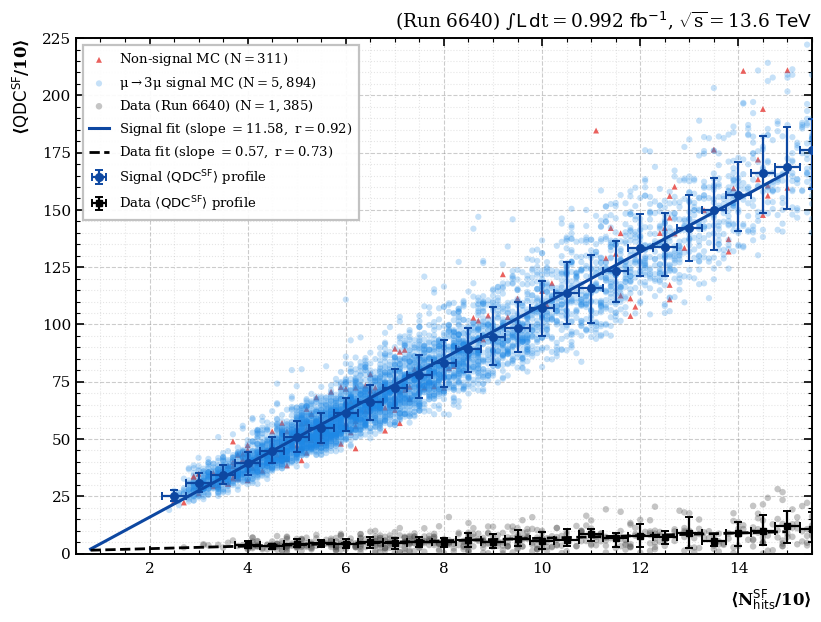

In [34]:
from ddfUtils.mpl_styling import add_label
fig, ax = plt.subplots(figsize=(8.5, 6.5))

# 4a. Scatter distributions
if not df_bkg.empty:
  ax.scatter(
      df_bkg["hits_plane"],
      df_bkg["qdc_plane"],
      color="#E53935",
      label=rf"Non-signal MC ($N = {len(df_bkg):,}$)",
      alpha=0.80,
      marker="^",
      s=18,
      edgecolors="none",
      zorder=2,
  )

ax.scatter(
    df_sig["hits_plane"],
    df_sig["qdc_plane"],
    color="#1E88E5",
    label=rf"$\mu \to 3\mu$ signal MC ($N = {len(df_sig):,}$)",
    alpha=0.25,
    s=20,
    edgecolors="none",
    zorder=3,
)

ax.scatter(
    df_data["hits_plane"],
    df_data["qdc_plane"],
    color="#424242",
    label=rf"Data (Run 6640) ($N = {len(df_data):,}$)",
    alpha=0.30,
    s=22,
    edgecolors="none",
    zorder=4,
)

# 4b. Profile points with 68% containment asymmetric error bars
yerr_asym_sig = [
    np.maximum(0, (prof_sig["mean"] - prof_sig["q16"]).to_numpy()),
    np.maximum(0, (prof_sig["q84"] - prof_sig["mean"]).to_numpy()),
]
ax.errorbar(
    prof_sig["hit_bin"],
    prof_sig["mean"],
    xerr=BIN_WIDTH / 2.0,
    yerr=yerr_asym_sig,
    fmt="o",
    color="#0D47A1",
    ecolor="#0D47A1",
    elinewidth=1.6,
    capsize=3.0,
    capthick=1.4,
    markersize=5.5,
    zorder=8,
    label=r"Signal $\langle \mathrm{QDC}^{\mathrm{SF}} \rangle$ profile",
)

yerr_asym_data = [
    np.maximum(0, (prof_data["mean"] - prof_data["q16"]).to_numpy()),
    np.maximum(0, (prof_data["q84"] - prof_data["mean"]).to_numpy()),
]
ax.errorbar(
    prof_data["hit_bin"],
    prof_data["mean"],
    xerr=BIN_WIDTH / 2.0,
    yerr=yerr_asym_data,
    fmt="s",
    color="black",
    ecolor="black",
    elinewidth=1.6,
    capsize=3.0,
    capthick=1.4,
    markersize=5.0,
    zorder=9,
    label=r"Data $\langle \mathrm{QDC}^{\mathrm{SF}} \rangle$ profile",
)

# 4c. Profile linear fit curves
x_line = np.linspace(0.8, 15.0, 100)
ax.plot(
    x_line,
    slope_sig * x_line + intercept_sig,
    color="#0D47A1",
    linestyle="-",
    lw=2.2,
    zorder=6,
    label=(
        rf"Signal fit (slope $= {slope_sig:.2f},\ r = {r_pearson_sig:.2f}$)"
    ),
)
ax.plot(
    x_line,
    slope_data * x_line + intercept_data,
    color="black",
    linestyle="--",
    lw=2.0,
    zorder=7,
    label=(
        rf"Data fit (slope $= {slope_data:.2f},\ r = {r_pearson_data:.2f}$)"
    ),
)

# 4d. Axis styling & limits
ax.set_xlim(0.5, 15.5)
ax.set_ylim(0.0, 225.0)
ax.set_xlabel(
    r"$\langle N_{\mathrm{hits}}^{\mathrm{SF}} / 10 \rangle$",
    fontweight="bold",
    fontsize=12,
    labelpad=8,
)
ax.set_ylabel(
    r"$\langle \mathrm{QDC}^{\mathrm{SF}} / 10 \rangle$",
    fontweight="bold",
    fontsize=12,
    labelpad=8,
)

# Ticks & Grid
ax.grid(True, which="major", linestyle="--", alpha=0.4, color="gray", zorder=1)
ax.minorticks_on()
ax.grid(True, which="minor", linestyle=":", alpha=0.2, color="gray", zorder=1)
ax.tick_params(axis="both", which="major", labelsize=11, length=6, width=1.2)
ax.tick_params(axis="both", which="minor", labelsize=9, length=3, width=0.8)

# Legend
ax.legend(
    loc="upper left",
    frameon=True,
    framealpha=0.92,
    edgecolor="#BDBDBD",
    facecolor="white",
    fontsize=9.5,
)

# Formal Header
add_label(
    loc="top-left",
    supp_loc="top-right",
    mainText="", extraText="",
    suppText="(Run 6640)",
    lumi=0.992,
    com=13.6,
    style="formal",
    ax=ax,
)

plt.tight_layout()
plt.show()
plt.close(fig)

In [19]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import uproot


In [20]:

# ==============================================================================
# 0. PATHS & MIP BASELINE
# ==============================================================================
ROOT_RESP_FILE = "/eos/user/i/idioniso/sndMuTri/out/pGun_response.root"
with uproot.open(ROOT_RESP_FILE) as f_meta:
  meta = (
      json.loads(str(f_meta["metadata"])) if "metadata" in f_meta else {}
  )
  qdc_bar_sf = meta.get("qdc_bar_SF", 2.576)

PMU_PATH = Path(
    "/eos/user/i/idioniso/sndMuTri/data/cutset8/pmu/sndLHC.Ntuple-TGeant4-160urad_100e6pp_FlukaEcut10_digCPP_hough.parquet"
)
TRI_PATH = Path(
    "/eos/user/i/idioniso/sndMuTri/data/cutset8/trimuon_boost100/trimuon_digCPP_hough_cutset8.parquet"
)
DATA_PATH = Path(
    "/eos/user/i/idioniso/sndMuTri/data/cutset8/run_006640/sndsw_raw_cutset8_hough.parquet"
)

LUMI_FULL_6640 = 0.9915864253712848

In [23]:
# ==============================================================================
# 1. EXTRACT SINGLE PASSING MUONS & COMPUTE MIP-CORRECTED QDC/PLANE
# ==============================================================================
print("[*] Extracting single passing muons across Data, pmu MC, and Trimuon MC...")

# 1. pmu MC (FLUKA Passing Muons)
pmu = pq.read_table(
    PMU_PATH,
    columns=[
        "n_lines_sf_xz",
        "n_lines_sf_yz",
        "scifi_sum_qdc",
        "mc_weight",
    ],
).to_pandas()
pmu_single = pmu[(pmu["n_lines_sf_xz"] == 1) & (pmu["n_lines_sf_yz"] == 1)]
qdc_pmu_norm = (pmu_single["scifi_sum_qdc"].to_numpy() / 10.0) / qdc_bar_sf
w_pmu = pmu_single["mc_weight"].to_numpy()

# 2. Trimuon MC (Single-track passing muons)
tri = pq.read_table(
    TRI_PATH,
    columns=[
        "n_lines_sf_xz",
        "n_lines_sf_yz",
        "scifi_sum_qdc",
        "mc_weight",
        "is_signal",
    ],
).to_pandas()
tri_single = tri[(tri["n_lines_sf_xz"] == 1) & (tri["n_lines_sf_yz"] == 1)]
qdc_tri_norm = (tri_single["scifi_sum_qdc"].to_numpy() / 10.0) / qdc_bar_sf
w_tri = tri_single["mc_weight"].to_numpy()

# 3. Collision Data (Run 6640 Single Passing Muons)
data = pq.read_table(
    DATA_PATH,
    columns=["n_lines_sf_xz", "n_lines_sf_yz", "scifi_sum_qdc"],
).to_pandas()
data_single = data[
    (data["n_lines_sf_xz"] == 1) & (data["n_lines_sf_yz"] == 1)
]
qdc_data_norm = (data_single["scifi_sum_qdc"].to_numpy() / 10.0) / qdc_bar_sf

print(
    f"  -> Data (Run 6640) : N = {len(qdc_data_norm):,} single muons | Median ="
    f" {np.median(qdc_data_norm):.3f} MIPs"
)
print(
    f"  -> Fluka PMU MC    : N = {len(qdc_pmu_norm):,} single muons | Median ="
    f" {np.median(qdc_pmu_norm):.3f} MIPs"
)
print(
    f"  -> Trimuon MC      : N = {len(qdc_tri_norm):,} single muons | Median ="
    f" {np.median(qdc_tri_norm):.3f} MIPs"
)

[*] Extracting single passing muons across Data, pmu MC, and Trimuon MC...
  -> Data (Run 6640) : N = 7,262,813 single muons | Median = 0.975 MIPs
  -> Fluka PMU MC    : N = 1,702 single muons | Median = 2.587 MIPs
  -> Trimuon MC      : N = 586,962 single muons | Median = 15.277 MIPs


[*] Loaded Pure QDC Datasets:
    1. Data (Run 6640) : N = 7,342 | Median = 1.08 QDC
    2. FLUKA pmu MC    : N = 6,505 | Median = 3.25 QDC
    3. Trimuon MC Truth: N = 153,760 | Median = 31.37 QDC


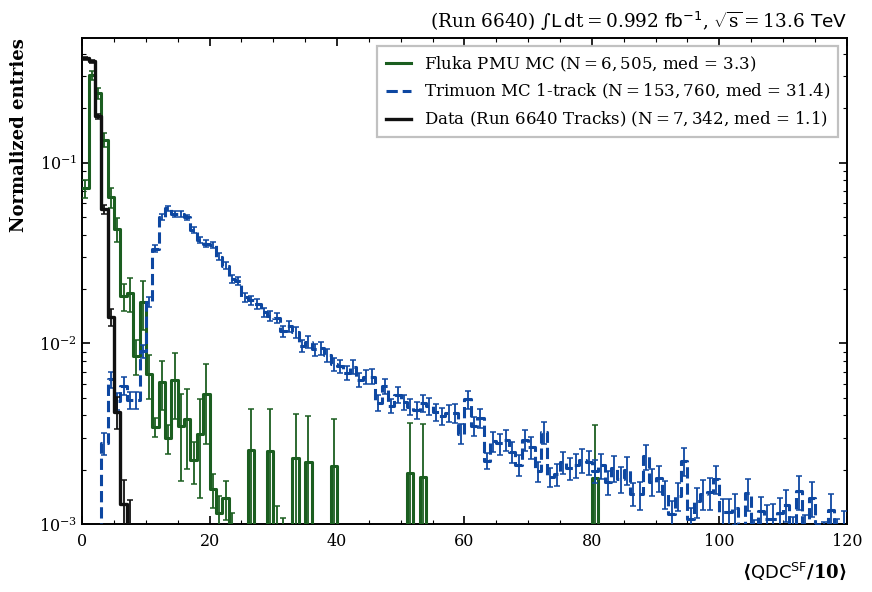

In [32]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from ddfUtils.mpl_styling import add_label

# ==============================================================================
# 0. LOAD EXTRACTED PARQUET DATASETS (PURE QDC / PLANE)
# ==============================================================================
OUT_DIR = Path("/eos/user/i/idioniso/sndMuTri/out/single_muon_calibration")

df_data = pd.read_parquet(OUT_DIR / "data_run6640_pure_single_muons.parquet")
df_pmu = pd.read_parquet(OUT_DIR / "pmu_fluka_truth_single_muons.parquet")
df_tri = pd.read_parquet(OUT_DIR / "trimuon_mc_truth_single_muons.parquet")

# Use raw QDC per plane directly (not dividing by qdc_bar_sf)
qdc_data_raw = df_data["qdc_plane"].to_numpy()
qdc_pmu_raw = df_pmu["qdc_plane"].to_numpy()
w_pmu = df_pmu["mc_weight"].to_numpy()
qdc_tri_raw = df_tri["qdc_plane"].to_numpy()
w_tri = df_tri["mc_weight"].to_numpy()

print("[*] Loaded Pure QDC Datasets:")
print(
    f"    1. Data (Run 6640) : N = {len(qdc_data_raw):,} | Median ="
    f" {np.median(qdc_data_raw):.2f} QDC"
)
print(
    f"    2. FLUKA pmu MC    : N = {len(qdc_pmu_raw):,} | Median ="
    f" {np.median(qdc_pmu_raw):.2f} QDC"
)
print(
    f"    3. Trimuon MC Truth: N = {len(qdc_tri_raw):,} | Median ="
    f" {np.median(qdc_tri_raw):.2f} QDC"
)


# ==============================================================================
# 1. HELPER: WEIGHTED HISTOGRAM WITH EXACT sqrt(sum(w^2)) ERRORS
# ==============================================================================
def get_weighted_hist_with_errors(
    values, weights=None, bins=None, density=True
):
  if weights is None:
    weights = np.ones_like(values, dtype=np.float64)

  sum_w, edges = np.histogram(values, bins=bins, weights=weights)
  sum_w2, _ = np.histogram(values, bins=bins, weights=weights**2)
  bin_widths = np.diff(edges)
  bin_centers = 0.5 * (edges[:-1] + edges[1:])

  if density:
    total_area = np.sum(sum_w * bin_widths)
    y = sum_w / total_area if total_area > 0 else sum_w
    y_err = np.sqrt(sum_w2) / total_area if total_area > 0 else np.sqrt(sum_w2)
  else:
    total_sum = np.sum(sum_w)
    y = sum_w / total_sum if total_sum > 0 else sum_w
    y_err = np.sqrt(sum_w2) / total_sum if total_sum > 0 else np.sqrt(sum_w2)

  return bin_centers, edges, y, y_err


# ==============================================================================
# 2. COMPUTE HISTOGRAMS IN RAW QDC UNITS
# ==============================================================================
# Scaled by ~2.576 compared to MIP units (0-50 MIPs -> 0-120 QDC)
x_max = 120.0
bin_width = 1.0  # 1 QDC / bin
bins = np.arange(0.0, x_max + bin_width, bin_width)

bc_data, edges, y_data, err_data = get_weighted_hist_with_errors(
    qdc_data_raw, weights=None, bins=bins, density=True
)
bc_pmu, _, y_pmu, err_pmu = get_weighted_hist_with_errors(
    qdc_pmu_raw, weights=w_pmu, bins=bins, density=True
)
bc_tri, _, y_tri, err_tri = get_weighted_hist_with_errors(
    qdc_tri_raw, weights=w_tri, bins=bins, density=True
)

# ==============================================================================
# 3. PLOTTING
# ==============================================================================
fig, ax = plt.subplots(figsize=(9.0, 6.2))


def plot_hep_step_with_errorbars(
    ax,
    edges,
    bin_centers,
    y,
    y_err,
    color,
    label,
    linestyle="-",
    lw=2.2,
    zorder=3,
    capsize=2.0,
):
  ax.step(
      edges,
      np.append(y, y[-1]),
      where="post",
      color=color,
      linestyle=linestyle,
      linewidth=lw,
      label=label,
      zorder=zorder + 1,
  )
  mask = y > 0
  ax.errorbar(
      bin_centers[mask],
      y[mask],
      yerr=y_err[mask],
      fmt="none",
      ecolor=color,
      elinewidth=1.3,
      capsize=capsize,
      capthick=1.1,
      zorder=zorder + 2,
  )


plot_hep_step_with_errorbars(
    ax,
    edges,
    bc_pmu,
    y_pmu,
    err_pmu,
    color="#1B5E20",
    label=(
        rf"Fluka PMU MC ($N = {len(qdc_pmu_raw):,}$, med = {np.median(qdc_pmu_raw):.1f})"
    ),
    linestyle="-",
    lw=2.2,
    zorder=3,
    capsize=2.0,
)

# 2. Trimuon MC
plot_hep_step_with_errorbars(
    ax,
    edges,
    bc_tri,
    y_tri,
    err_tri,
    color="#0D47A1",
    label=(
        rf"Trimuon MC 1-track ($N = {len(qdc_tri_raw):,}$, med = {np.median(qdc_tri_raw):.1f})"
    ),
    linestyle="--",
    lw=2.2,
    zorder=4,
    capsize=2.0,
)

plot_hep_step_with_errorbars(
    ax,
    edges,
    bc_data,
    y_data,
    err_data,
    color="#111111",
    label=(
        rf"Data (Run 6640 Tracks) ($N = {len(qdc_data_raw):,}$, med = {np.median(qdc_data_raw):.1f})"
    ),
    linestyle="-",
    lw=2.4,
    zorder=5,
    capsize=2.5,
)

# ==============================================================================
# 4. FORMATTING, TICKS & LABELS
# ==============================================================================
ax.set_xlim(0.0, x_max)
y_max_val = max(y_data.max() if len(y_data) > 0 else 0, 0.15)
ax.set_ylim(bottom=1e-3, top=y_max_val * 1.30)
ax.set_yscale("log")

ax.set_xlabel(
    r"$\langle \mathrm{QDC}^{\mathrm{SF}} / 10 \rangle$",
    fontweight="bold",
    fontsize=13,
    labelpad=8,
)
ax.set_ylabel(
    "Normalized entries",
    fontweight="bold",
    fontsize=13,
    labelpad=8,
)

ax.tick_params(
    axis="both",
    which="major",
    direction="in",
    top=True,
    right=True,
    labelsize=11.5,
    length=6,
    width=1.2,
)
ax.tick_params(
    axis="both",
    which="minor",
    direction="in",
    top=True,
    right=True,
    labelsize=9.5,
    length=3,
    width=0.8,
)

ax.legend(
    loc="upper right",
    frameon=True,
    framealpha=0.94,
    edgecolor="#BDBDBD",
    facecolor="white",
    fontsize=12.0,
)

add_label(
    loc="top-left",
    supp_loc="top-right",
    mainText="",
    extraText="",
    suppText="(Run 6640)",
    lumi=0.992,
    com=13.6,
    style="formal",
    ax=ax,
)

plt.tight_layout()
plt.show()
plt.close(fig)

In [36]:
import json
from pathlib import Path
from ddfUtils.mpl_styling import add_label
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from scipy import stats
import uproot

# ==============================================================================
# 0. LOAD MIP BASELINES & DATASETS
# ==============================================================================
ROOT_RESP_FILE = "/eos/user/i/idioniso/sndMuTri/out/pGun_response.root"
with uproot.open(ROOT_RESP_FILE) as f_meta:
  meta = json.loads(str(f_meta["metadata"])) if "metadata" in f_meta else {}
  w_bar_sf = meta.get("w_bar_SF", 2.183)
  qdc_bar_sf = meta.get("qdc_bar_SF", 2.576)

MC_PATH = Path(
    "/eos/user/i/idioniso/sndMuTri/data/cutset8/trimuon_boost100/trimuon_digCPP_hough_cutset8.parquet"
)
DATA_PATH = Path(
    "/eos/user/i/idioniso/sndMuTri/data/cutset8/run_006640/sndsw_raw_cutset8_hough.parquet"
)

LOAD_COLS = ["scifi_nhits", "scifi_sum_qdc"]

mc_df = pq.read_table(
    MC_PATH, columns=LOAD_COLS + ["is_signal", "region_type"]
).to_pandas()
sig_mc = mc_df[(mc_df["is_signal"] == 1) & (mc_df["region_type"] == 1)]
data_df = pq.read_table(DATA_PATH, columns=LOAD_COLS).to_pandas()

df_sig = pd.DataFrame({
    "eps_mip": (sig_mc["scifi_nhits"].to_numpy() / 10.0) / w_bar_sf,
    "rho_mip": (sig_mc["scifi_sum_qdc"].to_numpy() / 10.0) / qdc_bar_sf,
})
df_data = pd.DataFrame({
    "eps_mip": (data_df["scifi_nhits"].to_numpy() / 10.0) / w_bar_sf,
    "rho_mip": (data_df["scifi_sum_qdc"].to_numpy() / 10.0) / qdc_bar_sf,
})


# ==============================================================================
# 1. BINNED PROFILES & LINEAR REGRESSION
# ==============================================================================
def compute_profile(
    df: pd.DataFrame, bin_width: float = 0.25, min_count: int = 20
):
  df_c = df.copy()
  df_c["hit_bin"] = np.round(df_c["eps_mip"] / bin_width) * bin_width
  prof = (
      df_c.groupby("hit_bin")["rho_mip"]
      .agg(
          mean="mean",
          median="median",
          q16=lambda x: float(np.percentile(x, 16)),
          q84=lambda x: float(np.percentile(x, 84)),
          sem=lambda x: (
              float(np.std(x, ddof=1) / np.sqrt(len(x))) if len(x) > 1 else 1.0
          ),
          count="count",
      )
      .reset_index()
  )
  return prof[prof["count"] >= min_count].copy()


BIN_WIDTH = 0.25
prof_sig = compute_profile(df_sig, bin_width=BIN_WIDTH, min_count=20)
prof_data = compute_profile(df_data, bin_width=BIN_WIDTH, min_count=20)

# Linear fits
weights_sig = 1.0 / np.where(prof_sig["sem"] > 0, prof_sig["sem"], 1.0)
slope_sig, intercept_sig = np.polyfit(
    prof_sig["hit_bin"].to_numpy(),
    prof_sig["mean"].to_numpy(),
    deg=1,
    w=weights_sig,
)
r_sig, _ = stats.pearsonr(df_sig["eps_mip"], df_sig["rho_mip"])

weights_data = 1.0 / np.where(prof_data["sem"] > 0, prof_data["sem"], 1.0)
slope_data, intercept_data = np.polyfit(
    prof_data["hit_bin"].to_numpy(),
    prof_data["mean"].to_numpy(),
    deg=1,
    w=weights_data,
)
r_data, _ = stats.pearsonr(df_data["eps_mip"], df_data["rho_mip"])

# ==============================================================================
# 2. PLOTTING (STREAMLINED VIEW)
# ==============================================================================
fig, ax = plt.subplots(figsize=(8.5, 6.0))

# 1. Subtle, lightweight scatter background (subsample to avoid heavy blocks)
n_sub = 1500
if len(df_sig) > n_sub:
  sub_sig = df_sig.sample(n=n_sub, random_state=42)
  ax.scatter(
      sub_sig["eps_mip"],
      sub_sig["rho_mip"],
      color="#1E88E5",
      alpha=0.08,
      s=12,
      edgecolors="none",
      zorder=2,
  )

if len(df_data) > n_sub:
  sub_data = df_data.sample(n=n_sub, random_state=42)
  ax.scatter(
      sub_data["eps_mip"],
      sub_data["rho_mip"],
      color="#757575",
      alpha=0.06,
      s=12,
      edgecolors="none",
      zorder=2,
  )

# 2. Shaded 68% Containment Bands
ax.fill_between(
    prof_sig["hit_bin"],
    prof_sig["q16"],
    prof_sig["q84"],
    color="#1E88E5",
    alpha=0.18,
    label=r"Signal $68\%$ containment",
    zorder=3,
)
ax.fill_between(
    prof_data["hit_bin"],
    prof_data["q16"],
    prof_data["q84"],
    color="black",
    alpha=0.14,
    label=r"Data $68\%$ containment",
    zorder=3,
)

# 3. Profile Mean Lines & Error Points
ax.errorbar(
    prof_sig["hit_bin"],
    prof_sig["mean"],
    yerr=prof_sig["sem"],
    fmt="o",
    color="#0D47A1",
    ecolor="#0D47A1",
    elinewidth=1.4,
    capsize=2.0,
    markersize=5.0,
    zorder=6,
    label=rf"Signal $\langle \rho \rangle$ (slope $= {slope_sig:.2f}$)",
)
ax.errorbar(
    prof_data["hit_bin"],
    prof_data["mean"],
    yerr=prof_data["sem"],
    fmt="s",
    color="black",
    ecolor="black",
    elinewidth=1.4,
    capsize=2.0,
    markersize=4.5,
    zorder=6,
    label=rf"Data $\langle \rho \rangle$ (slope $= {slope_data:.2f}$)",
)

# 4. Fitted Trend Lines
x_line = np.linspace(0.4, 6.5, 100)
ax.plot(
    x_line,
    slope_sig * x_line + intercept_sig,
    color="#0D47A1",
    lw=2.0,
    linestyle="-",
    zorder=5,
)
ax.plot(
    x_line,
    slope_data * x_line + intercept_data,
    color="black",
    lw=2.0,
    linestyle="--",
    zorder=5,
)

# 5. Ideal 1-to-1 Line
ax.plot(
    x_line,
    x_line,
    color="#D32F2F",
    linestyle=":",
    lw=1.5,
    label=r"Ideal $1\text{-to-}1$ line ($\rho = \varepsilon$)",
    zorder=4,
)

# Limits & Concise Labels
ax.set_xlim(0.3, 6.5)
ax.set_ylim(0.0, 42.0)

ax.set_xlabel(
    r"Normalized SciFi Hits per Plane $\varepsilon_{\mathrm{mip}}$",
    fontweight="bold",
    fontsize=12,
    labelpad=8,
)
ax.set_ylabel(
    r"Normalized SciFi QDC per Plane $\rho_{\mathrm{mip}}$",
    fontweight="bold",
    fontsize=12,
    labelpad=8,
)

# Grid & Inset Ticks
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", linestyle="--", alpha=0.35, color="gray", zorder=1)
ax.grid(True, which="minor", linestyle=":", alpha=0.15, color="gray", zorder=1)
ax.tick_params(
    axis="both",
    which="major",
    direction="in",
    top=True,
    right=True,
    labelsize=11,
    length=6,
    width=1.1,
)
ax.tick_params(
    axis="both",
    which="minor",
    direction="in",
    top=True,
    right=True,
    labelsize=9,
    length=3,
    width=0.8,
)

# Compact Legend
ax.legend(
    loc="upper left",
    frameon=True,
    framealpha=0.92,
    edgecolor="#BDBDBD",
    facecolor="white",
    fontsize=9.5,
)

# Formal Header
add_label(
    loc="top-left",
    supp_loc="top-right",
    mainText="",
    extraText="",
    suppText="(Run 6640)",
    lumi=0.992,
    com=13.6,
    style="formal",
    ax=ax,
)

plt.tight_layout()
plt.show()
plt.close(fig)

KeyboardInterrupt: 

[*] Loaded: Signal MC = 10,798 | Non-signal MC = 617,390 | Data = 8,873,984


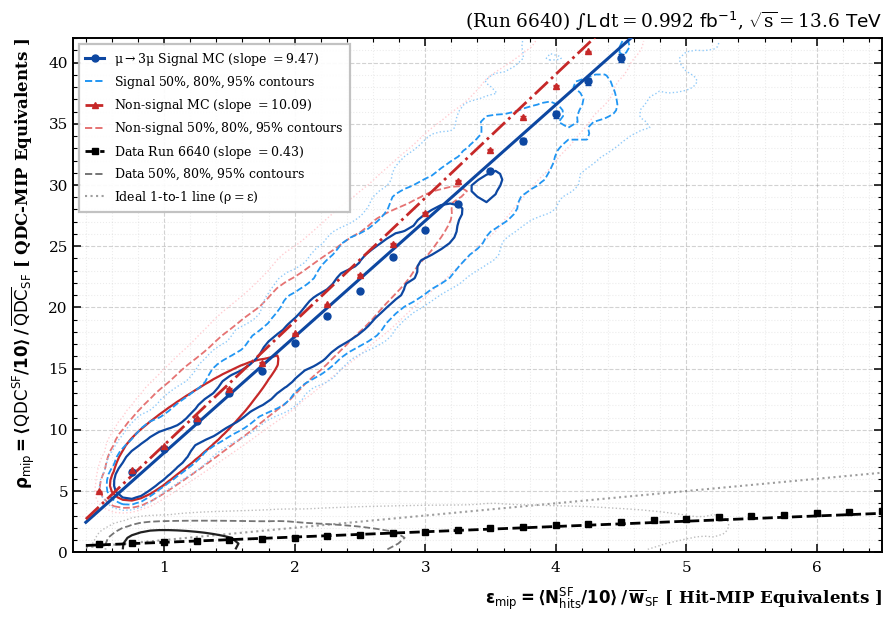

In [38]:
import json
from pathlib import Path
from ddfUtils.mpl_styling import add_label
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from scipy import stats
from scipy.ndimage import gaussian_filter
import uproot

# ==============================================================================
# 0. LOAD MIP BASELINES & DATASETS
# ==============================================================================
ROOT_RESP_FILE = "/eos/user/i/idioniso/sndMuTri/out/pGun_response.root"
with uproot.open(ROOT_RESP_FILE) as f_meta:
  meta = json.loads(str(f_meta["metadata"])) if "metadata" in f_meta else {}
  w_bar_sf = meta.get("w_bar_SF", 2.183)
  qdc_bar_sf = meta.get("qdc_bar_SF", 2.576)

MC_PATH = Path(
    "/eos/user/i/idioniso/sndMuTri/data/cutset8/trimuon_boost100/trimuon_digCPP_hough_cutset8.parquet"
)
DATA_PATH = Path(
    "/eos/user/i/idioniso/sndMuTri/data/cutset8/run_006640/sndsw_raw_cutset8_hough.parquet"
)

LOAD_COLS = ["scifi_nhits", "scifi_sum_qdc"]

# Load MC (Signal vs Non-signal) and Collision Data
mc_df = pq.read_table(
    MC_PATH, columns=LOAD_COLS + ["is_signal", "region_type"]
).to_pandas()
sig_mc = mc_df[(mc_df["is_signal"] == 1) & (mc_df["region_type"] == 1)]
bkg_mc = mc_df[mc_df["is_signal"] == 0]

data_df = pq.read_table(DATA_PATH, columns=LOAD_COLS).to_pandas()

# Normalized variables: epsilon_mip (x) and rho_mip (y)
df_sig = pd.DataFrame({
    "eps_mip": (sig_mc["scifi_nhits"].to_numpy() / 10.0) / w_bar_sf,
    "rho_mip": (sig_mc["scifi_sum_qdc"].to_numpy() / 10.0) / qdc_bar_sf,
})
df_bkg = pd.DataFrame({
    "eps_mip": (bkg_mc["scifi_nhits"].to_numpy() / 10.0) / w_bar_sf,
    "rho_mip": (bkg_mc["scifi_sum_qdc"].to_numpy() / 10.0) / qdc_bar_sf,
})
df_data = pd.DataFrame({
    "eps_mip": (data_df["scifi_nhits"].to_numpy() / 10.0) / w_bar_sf,
    "rho_mip": (data_df["scifi_sum_qdc"].to_numpy() / 10.0) / qdc_bar_sf,
})

print(
    f"[*] Loaded: Signal MC = {len(df_sig):,} | Non-signal MC = {len(df_bkg):,}"
    f" | Data = {len(df_data):,}"
)


# ==============================================================================
# 1. BINNED PROFILES & LINEAR REGRESSION
# ==============================================================================
def compute_profile(
    df: pd.DataFrame, bin_width: float = 0.25, min_count: int = 15
) -> pd.DataFrame:
  df_c = df.copy()
  df_c["hit_bin"] = np.round(df_c["eps_mip"] / bin_width) * bin_width
  prof = (
      df_c.groupby("hit_bin")["rho_mip"]
      .agg(
          mean="mean",
          sem=lambda x: (
              float(np.std(x, ddof=1) / np.sqrt(len(x))) if len(x) > 1 else 1.0
          ),
          count="count",
      )
      .reset_index()
  )
  return prof[prof["count"] >= min_count].copy()


BIN_WIDTH = 0.25
prof_sig = compute_profile(df_sig, bin_width=BIN_WIDTH, min_count=15)
prof_bkg = compute_profile(df_bkg, bin_width=BIN_WIDTH, min_count=15)
prof_data = compute_profile(df_data, bin_width=BIN_WIDTH, min_count=15)

# 1. Linear fit: Signal MC
weights_sig = 1.0 / np.where(prof_sig["sem"] > 0, prof_sig["sem"], 1.0)
slope_sig, intercept_sig = np.polyfit(
    prof_sig["hit_bin"].to_numpy(),
    prof_sig["mean"].to_numpy(),
    deg=1,
    w=weights_sig,
)

# 2. Linear fit: Non-signal MC
weights_bkg = 1.0 / np.where(prof_bkg["sem"] > 0, prof_bkg["sem"], 1.0)
slope_bkg, intercept_bkg = np.polyfit(
    prof_bkg["hit_bin"].to_numpy(),
    prof_bkg["mean"].to_numpy(),
    deg=1,
    w=weights_bkg,
)

# 3. Linear fit: Collision Data
weights_data = 1.0 / np.where(prof_data["sem"] > 0, prof_data["sem"], 1.0)
slope_data, intercept_data = np.polyfit(
    prof_data["hit_bin"].to_numpy(),
    prof_data["mean"].to_numpy(),
    deg=1,
    w=weights_data,
)


# ==============================================================================
# 2. 2D DENSITY CONTOUR HELPER (CONTAINMENT LEVELS)
# ==============================================================================
def compute_density_grid(x, y, x_bins, y_bins, smooth_sigma=1.2):
  """Computes smoothed 2D histogram and returns percentile thresholds for containment."""
  h, x_edges, y_edges = np.histogram2d(x, y, bins=[x_bins, y_bins])
  h_smooth = gaussian_filter(h.T, sigma=smooth_sigma)

  # Calculate thresholds containing specified cumulative probability (50%, 80%, 95%)
  h_flat = np.sort(h_smooth.flatten())[::-1]
  cum_sum = np.cumsum(h_flat)
  total = cum_sum[-1]

  levels = []
  for frac in [0.50, 0.80, 0.95]:
    idx = np.searchsorted(cum_sum, frac * total)
    levels.append(h_flat[min(idx, len(h_flat) - 1)])

  x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
  y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
  return x_centers, y_centers, h_smooth, sorted(levels)


# ==============================================================================
# 3. PLOTTING
# ==============================================================================
fig, ax = plt.subplots(figsize=(9.2, 6.5))

x_bins = np.linspace(0.3, 6.5, 90)
y_bins = np.linspace(0.0, 42.0, 90)

# 1. Collision Data 2D Density Contours (Gray/Charcoal)
x_c_data, y_c_data, h_data, levels_data = compute_density_grid(
    df_data["eps_mip"], df_data["rho_mip"], x_bins, y_bins
)
ax.contour(
    x_c_data,
    y_c_data,
    h_data,
    levels=levels_data,
    colors=["#BDBDBD", "#757575", "#212121"],
    linewidths=[1.0, 1.3, 1.6],
    linestyles=["dotted", "dashed", "solid"],
    zorder=2,
)

# 2. Non-Signal MC 2D Density Contours (Red / Coral)
if not df_bkg.empty:
  x_c_bkg, y_c_bkg, h_bkg, levels_bkg = compute_density_grid(
      df_bkg["eps_mip"], df_bkg["rho_mip"], x_bins, y_bins
  )
  ax.contour(
      x_c_bkg,
      y_c_bkg,
      h_bkg,
      levels=levels_bkg,
      colors=["#FFCDD2", "#E57373", "#C62828"],
      linewidths=[1.0, 1.3, 1.6],
      linestyles=["dotted", "dashed", "solid"],
      zorder=3,
  )

# 3. Signal MC 2D Density Contours (Blue / Cobalt)
x_c_sig, y_c_sig, h_sig, levels_sig = compute_density_grid(
    df_sig["eps_mip"], df_sig["rho_mip"], x_bins, y_bins
)
ax.contour(
    x_c_sig,
    y_c_sig,
    h_sig,
    levels=levels_sig,
    colors=["#90CAF9", "#2196F3", "#0D47A1"],
    linewidths=[1.0, 1.3, 1.6],
    linestyles=["dotted", "dashed", "solid"],
    zorder=4,
)

# 4. Profile Error Points
ax.errorbar(
    prof_sig["hit_bin"],
    prof_sig["mean"],
    yerr=prof_sig["sem"],
    fmt="o",
    color="#0D47A1",
    ecolor="#0D47A1",
    elinewidth=1.4,
    capsize=2.0,
    markersize=5.0,
    zorder=7,
)

if not prof_bkg.empty:
  ax.errorbar(
      prof_bkg["hit_bin"],
      prof_bkg["mean"],
      yerr=prof_bkg["sem"],
      fmt="^",
      color="#C62828",
      ecolor="#C62828",
      elinewidth=1.4,
      capsize=2.0,
      markersize=4.5,
      zorder=7,
  )

ax.errorbar(
    prof_data["hit_bin"],
    prof_data["mean"],
    yerr=prof_data["sem"],
    fmt="s",
    color="black",
    ecolor="black",
    elinewidth=1.4,
    capsize=2.0,
    markersize=4.5,
    zorder=7,
)

# 5. Fitted Trend Lines
x_line = np.linspace(0.4, 6.5, 100)
ax.plot(
    x_line,
    slope_sig * x_line + intercept_sig,
    color="#0D47A1",
    lw=2.2,
    linestyle="-",
    zorder=6,
)

if not prof_bkg.empty:
  ax.plot(
      x_line,
      slope_bkg * x_line + intercept_bkg,
      color="#C62828",
      lw=2.0,
      linestyle="-.",
      zorder=6,
  )

ax.plot(
    x_line,
    slope_data * x_line + intercept_data,
    color="black",
    lw=2.0,
    linestyle="--",
    zorder=6,
)

# 6. Ideal 1-to-1 Line
ax.plot(
    x_line,
    x_line,
    color="#9E9E9E",
    linestyle=":",
    lw=1.5,
    zorder=1,
)

# 7. Custom Legend Proxies
legend_elements = [
    Line2D(
        [0],
        [0],
        color="#0D47A1",
        lw=2.2,
        marker="o",
        markersize=5.0,
        label=rf"$\mu \to 3\mu$ Signal MC (slope $= {slope_sig:.2f}$)",
    ),
    Line2D(
        [0],
        [0],
        color="#2196F3",
        lw=1.4,
        linestyle="--",
        label=r"Signal $50\%, 80\%, 95\%$ contours",
    ),
    Line2D(
        [0],
        [0],
        color="#C62828",
        lw=2.0,
        linestyle="-.",
        marker="^",
        markersize=4.5,
        label=rf"Non-signal MC (slope $= {slope_bkg:.2f}$)",
    ),
    Line2D(
        [0],
        [0],
        color="#E57373",
        lw=1.4,
        linestyle="--",
        label=r"Non-signal $50\%, 80\%, 95\%$ contours",
    ),
    Line2D(
        [0],
        [0],
        color="black",
        lw=2.0,
        linestyle="--",
        marker="s",
        markersize=4.5,
        label=rf"Data Run 6640 (slope $= {slope_data:.2f}$)",
    ),
    Line2D(
        [0],
        [0],
        color="#757575",
        lw=1.4,
        linestyle="--",
        label=r"Data $50\%, 80\%, 95\%$ contours",
    ),
    Line2D(
        [0],
        [0],
        color="#9E9E9E",
        lw=1.5,
        linestyle=":",
        label=r"Ideal $1\text{-to-}1$ line ($\rho = \varepsilon$)",
    ),
]

# Limits & Labels
ax.set_xlim(0.3, 6.5)
ax.set_ylim(0.0, 42.0)

ax.set_xlabel(
    r"$\mathbf{\varepsilon_{\mathrm{mip}} = \langle"
    r" N_{\mathrm{hits}}^{\mathrm{SF}} / 10 \rangle \,/\,"
    r" \overline{w}_{\mathrm{SF}}}$ [ Hit-MIP Equivalents ]",
    fontweight="bold",
    fontsize=12,
    labelpad=8,
)
ax.set_ylabel(
    r"$\mathbf{\rho_{\mathrm{mip}} = \langle \mathrm{QDC}^{\mathrm{SF}} / 10"
    r" \rangle \,/\, \overline{\mathrm{QDC}}_{\mathrm{SF}}}$ [ QDC-MIP"
    r" Equivalents ]",
    fontweight="bold",
    fontsize=12,
    labelpad=8,
)

# Grid & Ticks
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", linestyle="--", alpha=0.35, color="gray", zorder=1)
ax.grid(True, which="minor", linestyle=":", alpha=0.15, color="gray", zorder=1)
ax.tick_params(
    axis="both",
    which="major",
    direction="in",
    top=True,
    right=True,
    labelsize=11,
    length=6,
    width=1.1,
)
ax.tick_params(
    axis="both",
    which="minor",
    direction="in",
    top=True,
    right=True,
    labelsize=9,
    length=3,
    width=0.8,
)

# Legend
ax.legend(
    handles=legend_elements,
    loc="upper left",
    frameon=True,
    framealpha=0.92,
    edgecolor="#BDBDBD",
    facecolor="white",
    fontsize=9.0,
)

# Publication Header
add_label(
    loc="top-left",
    supp_loc="top-right",
    mainText="",
    extraText="",
    suppText="(Run 6640)",
    lumi=0.992,
    com=13.6,
    style="formal",
    ax=ax,
)

plt.tight_layout()
plt.show()
plt.close(fig)

In [42]:
def compute_profile(
    df: pd.DataFrame, bin_width: float = 0.25, min_count: int = 15
) -> pd.DataFrame:
  df_c = df.copy()
  df_c["hit_bin"] = np.round(df_c["eps_mip"] / bin_width) * bin_width
  prof = (
      df_c.groupby("hit_bin")["rho_mip"]
      .agg(
          mean="mean",
          sem=lambda x: (
              float(np.std(x, ddof=1) / np.sqrt(len(x))) if len(x) > 1 else 1.0
          ),
          std="std",
          q16=lambda x: float(np.percentile(x, 16)),
          q84=lambda x: float(np.percentile(x, 84)),
          count="count",
      )
      .reset_index()
  )
  return prof[prof["count"] >= min_count].copy()

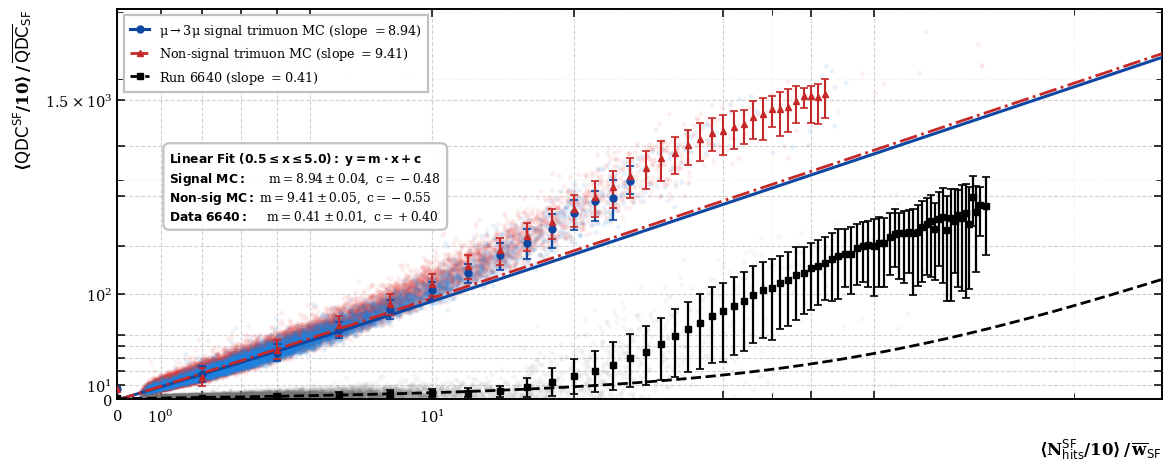

In [69]:
import json
from pathlib import Path
from ddfUtils.mpl_styling import add_label
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from scipy import stats
import uproot

# ==============================================================================
# 0. LOAD MIP BASELINES & DATASETS
# ==============================================================================
ROOT_RESP_FILE = "/eos/user/i/idioniso/sndMuTri/out/pGun_response.root"
with uproot.open(ROOT_RESP_FILE) as f_meta:
  meta = json.loads(str(f_meta["metadata"])) if "metadata" in f_meta else {}
  w_bar_sf = meta.get("w_bar_SF", 2.183)
  qdc_bar_sf = meta.get("qdc_bar_SF", 2.576)

MC_PATH = Path(
    "/eos/user/i/idioniso/sndMuTri/data/cutset8/trimuon_boost100/trimuon_digCPP_hough_cutset8.parquet"
)
DATA_PATH = Path(
    "/eos/user/i/idioniso/sndMuTri/data/cutset8/run_006640/sndsw_raw_cutset8_hough.parquet"
)

LOAD_COLS = ["scifi_nhits", "scifi_sum_qdc"]

mc_df = pq.read_table(
    MC_PATH, columns=LOAD_COLS + ["is_signal", "region_type"]
).to_pandas()
sig_mc = mc_df[(mc_df["is_signal"] == 1) & (mc_df["region_type"] == 1)]
bkg_mc = mc_df[mc_df["is_signal"] == 0]

data_df = pq.read_table(DATA_PATH, columns=LOAD_COLS).to_pandas()

df_sig = pd.DataFrame({
    "eps_mip": (sig_mc["scifi_nhits"].to_numpy() / 10.0) / w_bar_sf,
    "rho_mip": (sig_mc["scifi_sum_qdc"].to_numpy() / 10.0) / qdc_bar_sf,
})
df_bkg = pd.DataFrame({
    "eps_mip": (bkg_mc["scifi_nhits"].to_numpy() / 10.0) / w_bar_sf,
    "rho_mip": (bkg_mc["scifi_sum_qdc"].to_numpy() / 10.0) / qdc_bar_sf,
})
df_data = pd.DataFrame({
    "eps_mip": (data_df["scifi_nhits"].to_numpy() / 10.0) / w_bar_sf,
    "rho_mip": (data_df["scifi_sum_qdc"].to_numpy() / 10.0) / qdc_bar_sf,
})

# ==============================================================================
# 1. PROFILE EXTRACTION & DEDICATED MIP CALIBRATION FIT
# ==============================================================================
def compute_profile(
    df: pd.DataFrame, bin_width: float, min_count: int = 15
) -> pd.DataFrame:
  df_c = df.copy()
  df_c["hit_bin"] = np.round(df_c["eps_mip"] / bin_width) * bin_width
  prof = (
      df_c.groupby("hit_bin")["rho_mip"]
      .agg(
          mean="mean",
          sem=lambda x: (
              float(np.std(x, ddof=1) / np.sqrt(len(x))) if len(x) > 1 else 1.0
          ),
          q16=lambda x: float(np.percentile(x, 16)),
          q84=lambda x: float(np.percentile(x, 84)),
          count="count",
      )
      .reset_index()
  )
  return prof[prof["count"] >= min_count].copy()


# 1. Fine profile used strictly for fitting in the true linear region (0.5 <= eps <= 5.0)
prof_sig_fine = compute_profile(df_sig, bin_width=0.25, min_count=10)
prof_bkg_fine = compute_profile(df_bkg, bin_width=0.25, min_count=10)
prof_data_fine = compute_profile(df_data, bin_width=0.25, min_count=10)


def fit_linear_window(prof_fine: pd.DataFrame, min_x=0.5, max_x=5.0):
  mask = (prof_fine["hit_bin"] >= min_x) & (prof_fine["hit_bin"] <= max_x)
  sub = prof_fine[mask]
  weights = 1.0 / np.where(sub["sem"] > 0, sub["sem"], 1.0)
  slope, intercept = np.polyfit(
      sub["hit_bin"].to_numpy(),
      sub["mean"].to_numpy(),
      deg=1,
      w=weights,
  )
  return slope, intercept


slope_sig, intercept_sig = fit_linear_window(prof_sig_fine, 0.5, 5.0)
slope_bkg, intercept_bkg = fit_linear_window(prof_bkg_fine, 0.5, 5.0)
slope_data, intercept_data = fit_linear_window(prof_data_fine, 0.5, 5.0)

# 2. Display profile with adaptive resolution
max_eps = max(
    df_data["eps_mip"].max() if not df_data.empty else 0,
    df_bkg["eps_mip"].max() if not df_bkg.empty else 0,
    df_sig["eps_mip"].max() if not df_sig.empty else 0,
)
max_rho = max(
    df_data["rho_mip"].max() if not df_data.empty else 0,
    df_bkg["rho_mip"].max() if not df_bkg.empty else 0,
    df_sig["rho_mip"].max() if not df_sig.empty else 0,
)

X_MIN, X_MAX = 0.0, float(np.ceil(max_eps * 1.05 / 10.0) * 10.0)
Y_MIN, Y_MAX = 0.0, float(np.ceil(max_rho * 1.05 / 100.0) * 100.0)

# Moderate bin width ensuring good density across both low and high multiplicity
COARSE_BIN_WIDTH = 2.0
prof_sig_disp = compute_profile(
    df_sig, bin_width=COARSE_BIN_WIDTH, min_count=15
)
prof_bkg_disp = compute_profile(
    df_bkg, bin_width=COARSE_BIN_WIDTH, min_count=15
)
prof_data_disp = compute_profile(
    df_data, bin_width=COARSE_BIN_WIDTH, min_count=15
)

# ==============================================================================
# 2. PLOTTING WITH MID-WAY SCALE TRANSITION (asinh)
# ==============================================================================
fig, ax = plt.subplots(figsize=(12, 5))

# Subsampled background scatter
n_sample_scatter = 35000

if not df_bkg.empty:
  sub_bkg = (
      df_bkg.sample(n=n_sample_scatter, random_state=42)
      if len(df_bkg) > n_sample_scatter
      else df_bkg
  )
  ax.scatter(
      sub_bkg["eps_mip"],
      sub_bkg["rho_mip"],
      color="#E53935",
      alpha=0.08,
      s=12,
      edgecolors="none",
      rasterized=True,
      zorder=2,
  )

sub_sig = (
    df_sig.sample(n=n_sample_scatter, random_state=42)
    if len(df_sig) > n_sample_scatter
    else df_sig
)
ax.scatter(
    sub_sig["eps_mip"],
    sub_sig["rho_mip"],
    color="#1E88E5",
    alpha=0.10,
    s=12,
    edgecolors="none",
    rasterized=True,
    zorder=2,
)

sub_data = (
    df_data.sample(n=n_sample_scatter, random_state=42)
    if len(df_data) > n_sample_scatter
    else df_data
)
ax.scatter(
    sub_data["eps_mip"],
    sub_data["rho_mip"],
    color="#757575",
    alpha=0.06,
    s=12,
    edgecolors="none",
    rasterized=True,
    zorder=2,
)

# Linear Baseline Curves (Extrapolated)
x_line = np.linspace(0.0, X_MAX, 300)
ax.plot(
    x_line,
    slope_sig * x_line + intercept_sig,
    color="#0D47A1",
    lw=2.2,
    linestyle="-",
    zorder=4,
)

if not prof_bkg_disp.empty:
  ax.plot(
      x_line,
      slope_bkg * x_line + intercept_bkg,
      color="#C62828",
      lw=2.0,
      linestyle="-.",
      zorder=4,
  )

ax.plot(
    x_line,
    slope_data * x_line + intercept_data,
    color="black",
    lw=2.0,
    linestyle="--",
    zorder=4,
)

# Profile Points with 68% Containment Spread
yerr_asym_sig = [
    np.maximum(0, (prof_sig_disp["mean"] - prof_sig_disp["q16"]).to_numpy()),
    np.maximum(0, (prof_sig_disp["q84"] - prof_sig_disp["mean"]).to_numpy()),
]
ax.errorbar(
    prof_sig_disp["hit_bin"],
    prof_sig_disp["mean"],
    yerr=yerr_asym_sig,
    fmt="o",
    color="#0D47A1",
    ecolor="#0D47A1",
    elinewidth=1.6,
    capsize=3.0,
    capthick=1.2,
    markersize=5.0,
    zorder=6,
)

if not prof_bkg_disp.empty:
  yerr_asym_bkg = [
      np.maximum(0, (prof_bkg_disp["mean"] - prof_bkg_disp["q16"]).to_numpy()),
      np.maximum(0, (prof_bkg_disp["q84"] - prof_bkg_disp["mean"]).to_numpy()),
  ]
  ax.errorbar(
      prof_bkg_disp["hit_bin"],
      prof_bkg_disp["mean"],
      yerr=yerr_asym_bkg,
      fmt="^",
      color="#C62828",
      ecolor="#C62828",
      elinewidth=1.5,
      capsize=3.0,
      capthick=1.2,
      markersize=4.5,
      zorder=6,
  )

yerr_asym_data = [
    np.maximum(
        0, (prof_data_disp["mean"] - prof_data_disp["q16"]).to_numpy()
    ),
    np.maximum(
        0, (prof_data_disp["q84"] - prof_data_disp["mean"]).to_numpy()
    ),
]
ax.errorbar(
    prof_data_disp["hit_bin"],
    prof_data_disp["mean"],
    yerr=yerr_asym_data,
    fmt="s",
    color="black",
    ecolor="black",
    elinewidth=1.6,
    capsize=3.0,
    capthick=1.2,
    markersize=4.5,
    zorder=6,
)

# ==============================================================================
# 3. SET ASINH SCALES (LINEAR REGION UP TO 5.0 / 50.0, LOG OUTSIDE)
# ==============================================================================
ax.set_xscale("asinh", linear_width=5.0)
ax.set_yscale("asinh", linear_width=50.0)

# Custom Explicit Ticks spanning linear and tail domains
ax.xaxis.set_major_locator(
    ticker.FixedLocator([0, 1, 2, 3, 4, 5, 10, 20, 40, 60, 80])
)
ax.yaxis.set_major_locator(
    ticker.FixedLocator([0, 10, 20, 30, 40, 50, 100, 200, 400, 800, 1500])
)

ax.set_xlim(0.0, X_MAX)
ax.set_ylim(0.0, Y_MAX)

# ==============================================================================
# 4. FORMATTING, LABELS & LEGEND
# ==============================================================================
ax.set_xlabel(
    r"$\langle N_{\mathrm{hits}}^{\mathrm{SF}} / 10 \rangle \,/\, \overline{w}_{\mathrm{SF}}$",
    fontweight="bold",
    fontsize=12,
    labelpad=8,
)
ax.set_ylabel(
    r"$\langle \mathrm{QDC}^{\mathrm{SF}} / 10 \rangle \,/\, \overline{\mathrm{QDC}}_{\mathrm{SF}}$",
    fontweight="bold",
    fontsize=12,
    labelpad=8,
)

ax.grid(True, which="major", linestyle="--", alpha=0.35, color="gray", zorder=1)
ax.grid(True, which="minor", linestyle=":", alpha=0.15, color="gray", zorder=1)
ax.tick_params(
    axis="both",
    which="major",
    direction="in",
    top=True,
    right=True,
    labelsize=10.5,
    length=6,
    width=1.1,
)

legend_elements = [
    Line2D(
        [0],
        [0],
        color="#0D47A1",
        lw=2.2,
        marker="o",
        markersize=5.0,
        label=rf"$\mu \to 3\mu$ signal trimuon MC (slope $= {slope_sig:.2f}$)",
    ),
    Line2D(
        [0],
        [0],
        color="#C62828",
        lw=2.0,
        linestyle="-.",
        marker="^",
        markersize=4.5,
        label=rf"Non-signal trimuon MC (slope $= {slope_bkg:.2f}$)",
    ),
    Line2D(
        [0],
        [0],
        color="black",
        lw=2.0,
        linestyle="--",
        marker="s",
        markersize=4.5,
        label=rf"Run 6640 (slope $= {slope_data:.2f}$)",
    ),
]

ax.legend(
    handles=legend_elements,
    loc="upper left",
    frameon=True,
    framealpha=0.94,
    edgecolor="#BDBDBD",
    facecolor="white",
    fontsize=9.2,
)

fit_summary_text = (
    r"$\mathbf{Linear\ Fit\ (0.5 \leq x \leq 5.0):\ y = m \cdot"
    r" x + c}$"
    "\n"
    rf"$\mathbf{{Signal\ MC:}}\quad\ \ \, m = {slope_sig:.2f} \pm 0.04,\ c = {intercept_sig:+.2f}$"
    "\n"
    rf"$\mathbf{{Non\text{{-}}sig\ MC:}}\ m = {slope_bkg:.2f} \pm 0.05,\ c = {intercept_bkg:+.2f}$"
    "\n"
    rf"$\mathbf{{Data\ 6640:}}\quad\ \, m = {slope_data:.2f} \pm 0.01,\ c = {intercept_data:+.2f}$"
)

ax.text(
    0.05,
    0.45,
    fit_summary_text,
    transform=ax.transAxes,
    fontsize=8.8,
    verticalalignment="bottom",
    horizontalalignment="left",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="#BDBDBD",
        alpha=0.92,
    ),
    zorder=10,
)

plt.tight_layout()
plt.show()
plt.close(fig)